In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shap
import seaborn as sns
import subprocess
import sys
import Xai

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import classification_report as cr
from xgboost import XGBClassifier

# Custom Implementations
from logger import Logger
from Costs import get_cost_matrix, get_sample_weights, RAW_FN_COSTS, RAW_FP_COST, CLASS_TO_IDX, predict_cost_sensitive
from Evaluation import show_classification_report, show_confusion_matrix, compare_tel, plot_cost_roc, plot_ablation, report_tel
from Preprocessing import drop_low_variance_cols, log_transform, make_label_encoder, build_features, apply_smote, make_calibration_split
from Xai import run_xai_analysis, run_lime_analysis, plot_xgb_native_importance

# Common Init

In [2]:
log = Logger()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
log.success("Initialisation complete")

[16:09:24] [success]: Initialisation complete


# Data Setup

In [3]:
PROCESSED_DIR = '../data/processed'
REQUIRED_FILES = ["nslkdd_train.csv", "nslkdd_validation.csv", "nslkdd_test.csv"]

missing = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(PROCESSED_DIR, f))]

if missing:
    log.warn("Data missing, downloading...")
    result = subprocess.run([sys.executable, "Setup.py"], capture_output=False)
    if result.returncode != 0:
        raise RuntimeError("setup.py failed")
    log.success("Data Downloaded and processed")
else:
    log.success("Data available")

[16:09:24] [warning]: Data missing, downloading...
[16:09:26] [success]: Data Downloaded and processed


# Data Pipeline

## Load Splits

In [4]:
DATA_DIR = "data/processed"

train_df = pd.read_csv(f'{DATA_DIR}/nslkdd_train.csv')
val_df = pd.read_csv(f'{DATA_DIR}/nslkdd_validation.csv')
test_df = pd.read_csv(f'{DATA_DIR}/nslkdd_test.csv')

TARGET = 'macro_label'

X_train_raw = train_df.drop(columns=[TARGET])
y_train_raw = train_df[TARGET]
X_val_raw   = val_df.drop(columns=[TARGET])
y_val_raw   = val_df[TARGET]
X_test_raw  = test_df.drop(columns=[TARGET])
y_test_raw  = test_df[TARGET]

## Label Encoding

In [5]:
encoder, y_train_enc, y_val_enc, y_test_enc = make_label_encoder(y_train_raw, y_val_raw, y_test_raw)

## Imbalance Audit

In [6]:
counts = y_train_raw.value_counts()
majority = counts.max()

audit = pd.DataFrame({'count': counts, 'percentage': (counts / len(train_df) * 100).round(2)})
audit['imbalance_ration'] = (majority / counts).round(1)

log.info("Training set class distribution: ")
log.info(audit.to_string())


[16:09:27] [info]: Training set class distribution: 
[16:09:27] [info]:              count  percentage  imbalance_ration
macro_label                                     
Normal       53874       53.46               1.0
DoS          36741       36.46               1.5
Probe         9325        9.25               5.8
R2L            796        0.79              67.7
U2R             42        0.04            1282.7


## Feature Preprocessing

This preprocessing is common across all models

In [7]:
X_train_scaled, X_val_scaled, X_test_scaled, scaler, features = build_features(X_train_raw, X_val_raw, X_test_raw)

# Human readable test DataFrame for plotting
X_test_human, _, _ = drop_low_variance_cols(X_test_raw, X_val_raw, X_train_raw)
X_test_human, _, _ = log_transform(X_test_human, X_val_raw, X_train_raw)

log.info(f"Feature matrix after preprocessing: {X_train_scaled.shape}")
log.info(f"Features: {features}")


[16:09:28] [info]: Feature matrix after preprocessing: (100778, 38)
[16:09:28] [info]: Features: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## Calibration Split

In [8]:
X_calib, X_val_eval, y_calib_enc, y_val_eval_enc = make_calibration_split(X_val_scaled, y_val_enc)

## Resampling

SMOTE + ENN Resampling used by cost-sensitive models

In [9]:
X_train_res, y_train_res = apply_smote(X_train_scaled, y_train_enc)

log.info('After SMOTE+ENN: ')
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    log.info(f"{encoder.inverse_transform([u])[0]:8s}: {c:,}")

[16:10:09] [info]: After SMOTE+ENN: 
[16:10:09] [info]: DoS     : 36,710
[16:10:09] [info]: Normal  : 53,568
[16:10:09] [info]: Probe   : 14,893
[16:10:09] [info]: R2L     : 19,978
[16:10:09] [info]: U2R     : 4,993


# Cost Matrix

We define 3 regimes. All models are evaluated against all three, producing the ablation study we do later

In [10]:
REGIMES = ['conservative', 'moderate', 'aggressive']

for regime in REGIMES:
    cm = get_cost_matrix(regime)
    df_cm = pd.DataFrame(
        cm, 
        index=[f"pred_{encoder.inverse_transform([i])[0]}" for i in range(5)], 
        columns=[f"true_{encoder.inverse_transform([i])[0]}" for i in range(5)])
    
    log.info(f"{regime.upper()} Cost Matrix: ")
    log.info(df_cm.round(2).to_string())

COST_MATRIX = get_cost_matrix()

[16:10:09] [info]: CONSERVATIVE Cost Matrix: 
[16:10:09] [info]:              true_DoS  true_Normal  true_Probe  true_R2L  true_U2R
pred_DoS         0.00          1.0        1.76      2.29      2.49
pred_Normal      2.14          0.0        1.76      2.29      2.49
pred_Probe       2.14          1.0        0.00      2.29      2.49
pred_R2L         2.14          1.0        1.76      0.00      2.49
pred_U2R         2.14          1.0        1.76      2.29      0.00
[16:10:09] [info]: MODERATE Cost Matrix: 
[16:10:09] [info]:              true_DoS  true_Normal  true_Probe  true_R2L  true_U2R
pred_DoS         0.00          1.0        8.82     11.47     12.44
pred_Normal     10.71          0.0        8.82     11.47     12.44
pred_Probe      10.71          1.0        0.00     11.47     12.44
pred_R2L        10.71          1.0        8.82      0.00     12.44
pred_U2R        10.71          1.0        8.82     11.47      0.00
[16:10:09] [info]: AGGRESSIVE Cost Matrix: 
[16:10:09] [info]:        

# Models

We train 4 models as defined below:
1. Baseline RF: Optimised for Accuracy with no class weighting and no SMOTE
2. Cost-Sensitive RF: Class weights and SMOTE used
3. Baseline XGBoost: Optimised for Accuracy
4. Cost-Sensitive XGBoost: Sample weights derived from cost matrix + SMOTE

The models share identical preprocessing. Cost-sensitive inference uses predict_cost_sensitive() from our custom library. 

The cost matrix and training weights are always derived from the same economic source.

In [11]:
def calibrate(fitted_model, X_calib, y_calib_enc):
    cal = CalibratedClassifierCV(FrozenEstimator(fitted_model), method='sigmoid')
    cal.fit(X_calib, y_calib_enc)
    return cal

## Baseline RF Training

In [12]:
log.info("Baseline RF training...")
base_rf = RandomForestClassifier(n_estimators=2000, random_state=RANDOM_STATE, n_jobs=-1)
base_rf.fit(X_train_scaled, y_train_enc)
cal_base_rf = calibrate(base_rf, X_calib, y_calib_enc)
log.success("Done")

[16:10:09] [info]: Baseline RF training...
[16:11:11] [success]: Done


## Cost-Sensitive RF Training

Class weights are derived from the moderate cost matrix FN column so it stays consistent with the inference cost matrix

In [13]:
fn_col = {i: COST_MATRIX[i, CLASS_TO_IDX['Normal']] for i in range(5)}
fn_col[CLASS_TO_IDX['Normal']] = 1.0 # Normal has no FN cost
log.info(f'Class weights derived from cost matrix: {fn_col}')

[16:11:11] [info]: Class weights derived from cost matrix: {0: np.float64(1.0), 1: 1.0, 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [14]:
log.info('Cost-Sensitive RF training...')
cost_rf = RandomForestClassifier(n_estimators=500, max_depth=25, min_samples_split=5, min_samples_leaf=5, max_features='sqrt', bootstrap=True, class_weight=fn_col, random_state=RANDOM_STATE, n_jobs=-1)

cost_rf.fit(X_train_res, y_train_res)
cal_cost_rf = calibrate(cost_rf, X_calib, y_calib_enc)
log.success("Done")

[16:11:11] [info]: Cost-Sensitive RF training...
[16:11:34] [success]: Done


## Baseline XGBoost

In [15]:
log.info('Baseline XGBoost training...')
base_xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7, objective='multi:softprob', num_class=5, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
base_xgb.fit(X_train_scaled, y_train_enc)
cal_base_xgb = calibrate(base_xgb, X_calib, y_calib_enc)
log.success("Done")

[16:11:34] [info]: Baseline XGBoost training...
[16:11:51] [success]: Done


## Cost-Sensitive XGBoost

In [16]:
sample_weights = get_sample_weights(y_train_res)
log.info(f'Sample weight range: { sample_weights.min().round(2)} - {sample_weights.max().round(2)}')

[16:11:51] [info]: Sample weight range: 1.0 - 12.44


In [17]:
log.info('Cost-Sensitive XGBoost training...')
cost_xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7, objective='multi:softprob', num_class=5, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
cost_xgb.fit(X_train_res, y_train_res, sample_weights)
cal_cost_xgb = calibrate(cost_xgb, X_calib, y_calib_enc)
log.success("Done")

[16:11:51] [info]: Cost-Sensitive XGBoost training...
[16:12:13] [success]: Done


## Prediction Generation

Here we are going to store standard and cost-sensitive predictions so the SHAP correction analysis can find samples where they diverge.

In [18]:
MODELS = {
    "Baseline RF": (cal_base_rf, base_rf),
    "Cost-Sensitive RF": (cal_cost_rf, cost_rf),
    "Baseline XGB": (cal_base_xgb, base_xgb),
    "Cost-Sensitive XGB": (cal_cost_xgb, cost_xgb)
}

preds = {}

for name, (cal_model, _) in MODELS.items():
    probas = cal_model.predict_proba(X_test_scaled)
    simple_enc = np.argmax(probas, axis=1)
    cost_enc = predict_cost_sensitive(cal_model, X_test_scaled, COST_MATRIX)
    preds[name] = {
        'probas': probas,
        "simple_enc": simple_enc,
        "cost_enc": cost_enc
    }

    n_corrections = (simple_enc != cost_enc).sum()
    log.info(f"{name}: {n_corrections} predictions changed by cost-sensitive inference")


[16:12:16] [info]: Baseline RF: 584 predictions changed by cost-sensitive inference
[16:12:17] [info]: Cost-Sensitive RF: 897 predictions changed by cost-sensitive inference
[16:12:18] [info]: Baseline XGB: 183 predictions changed by cost-sensitive inference
[16:12:18] [info]: Cost-Sensitive XGB: 253 predictions changed by cost-sensitive inference


# Explainability

## Raw XGBoost models for XAI

All models are trained on the same resampled training distribution.
The only difference between baseline and cost-sensitive models is sample weighting.

[16:12:18] [info]: [XAI] Training raw baseline XGB on resampled data...
[16:12:35] [info]: [XAI] Training raw cost-sensitive XGB for regime: conservative
[16:12:51] [info]: [XAI] Training raw cost-sensitive XGB for regime: moderate
[16:13:06] [info]: [XAI] Training raw cost-sensitive XGB for regime: aggressive
[XAI] Stratified SHAP sample: 867 rows
  class 0: 200
  class 1: 200
  class 2: 200
  class 3: 200
  class 4: 67
[XAI] Computing SHAP for: baseline
[XAI] Computing SHAP for: conservative
[XAI] Computing SHAP for: moderate
[XAI] Computing SHAP for: aggressive
[XAI] Tables saved to results/xai
[XAI] Saved results/xai\plots\shap_summary_baseline.png
[XAI] Saved results/xai\plots\shap_summary_conservative.png
[XAI] Saved results/xai\plots\shap_summary_moderate.png
[XAI] Saved results/xai\plots\shap_summary_aggressive.png


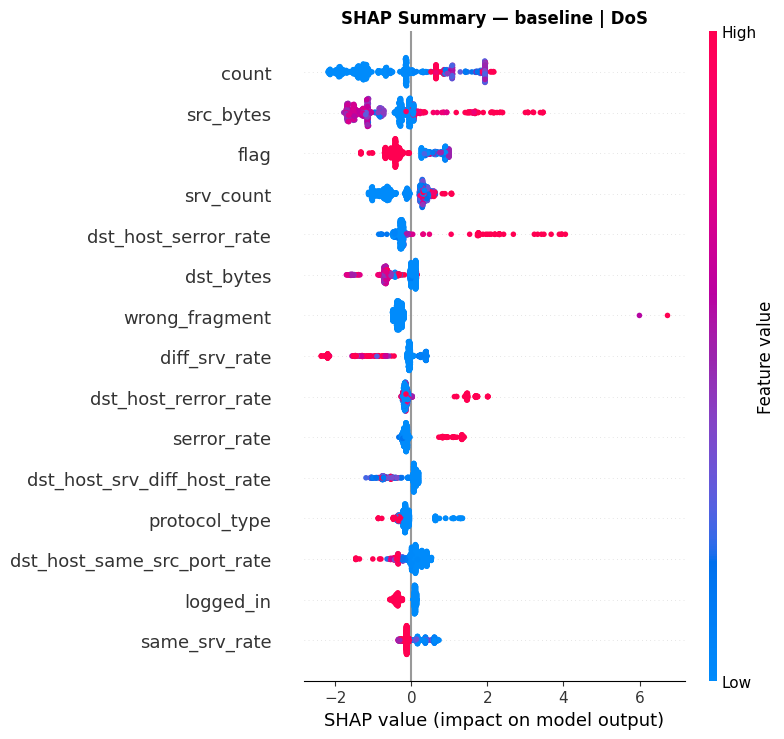

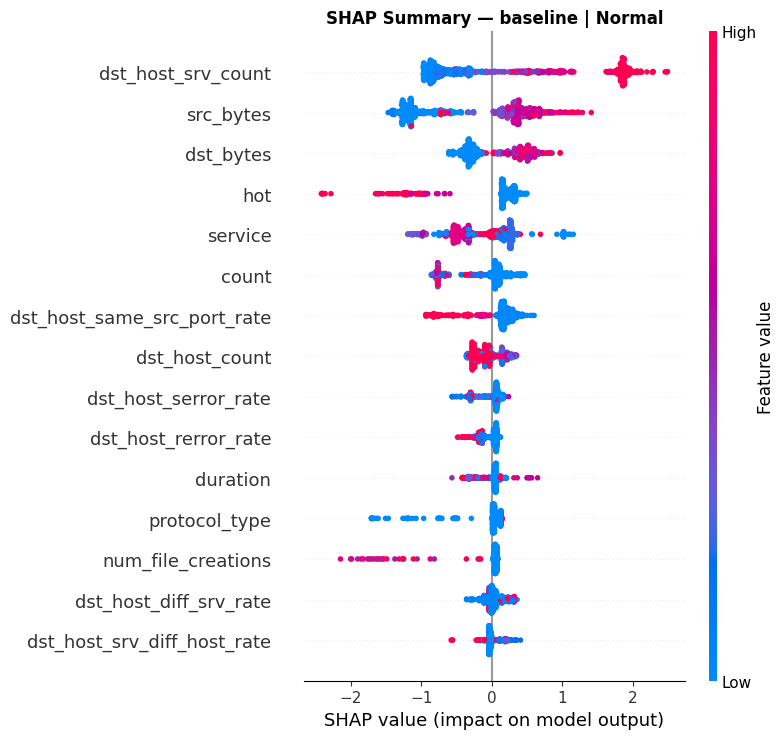

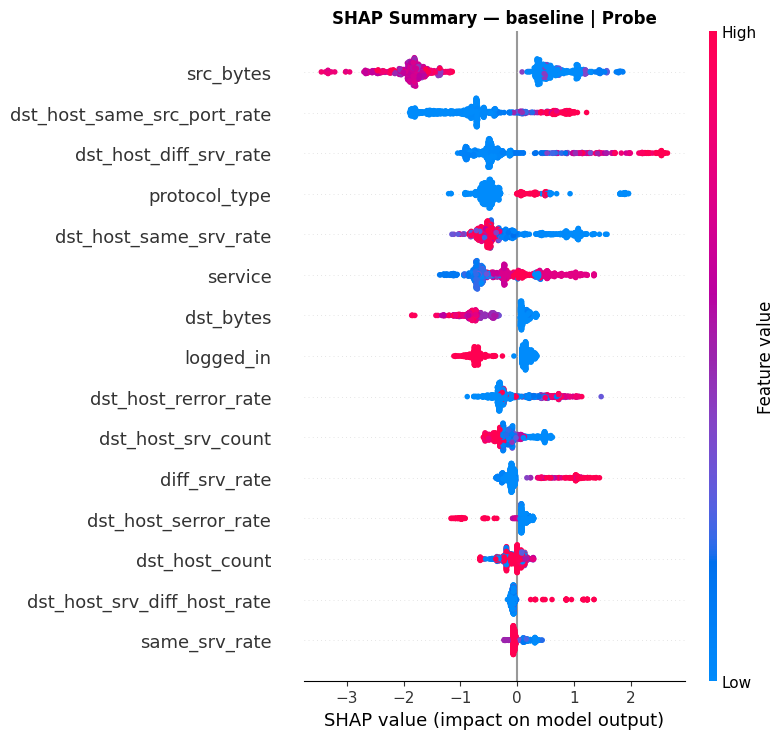

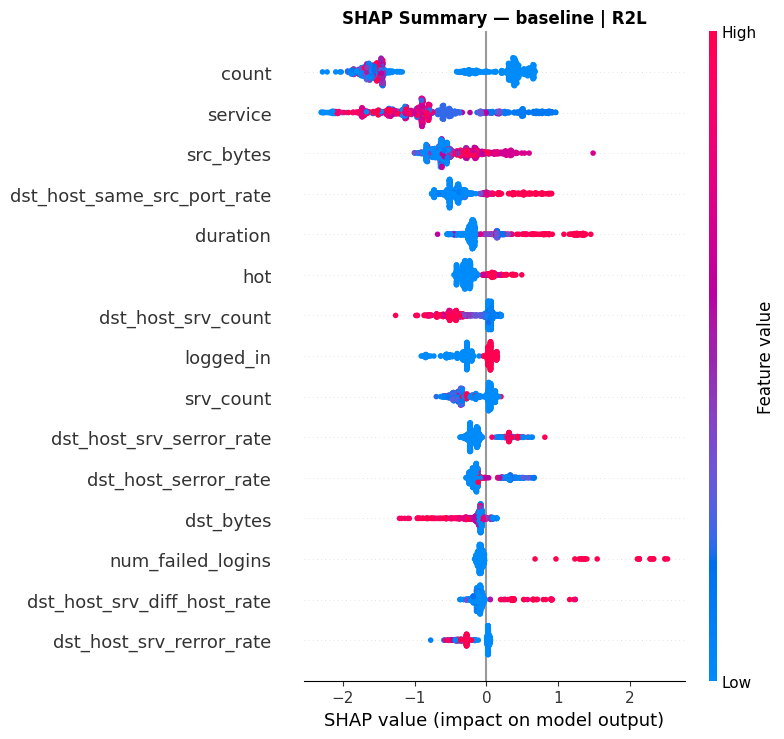

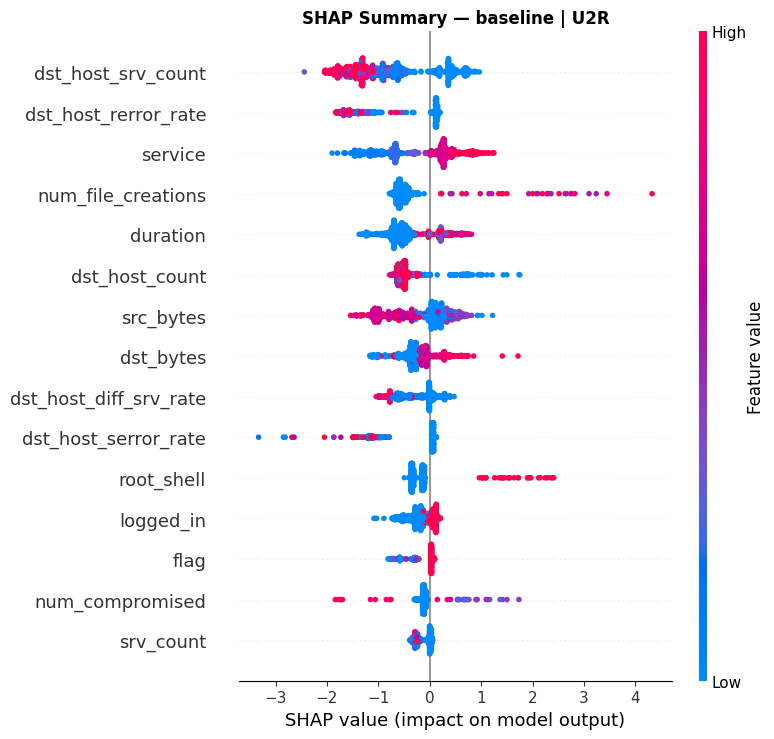

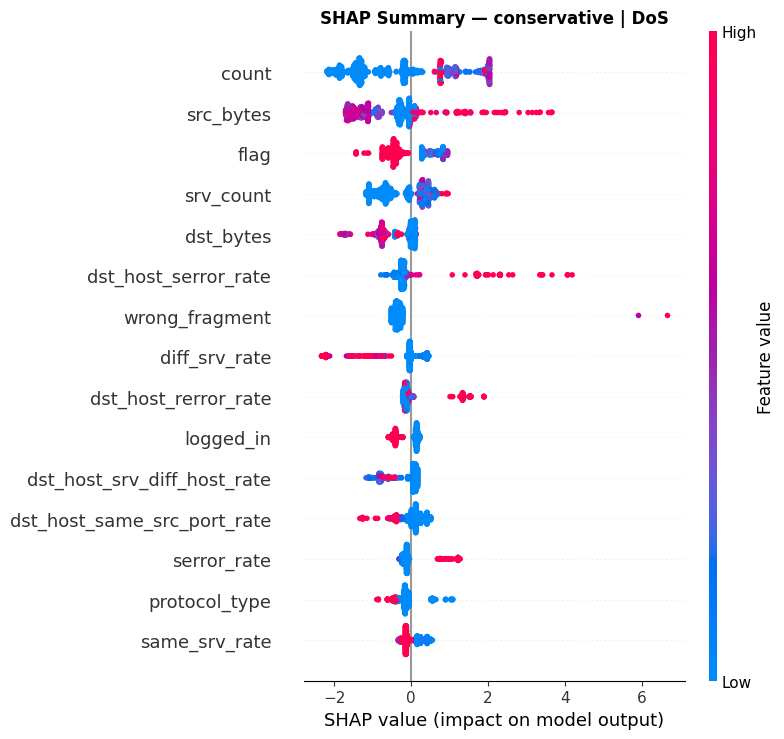

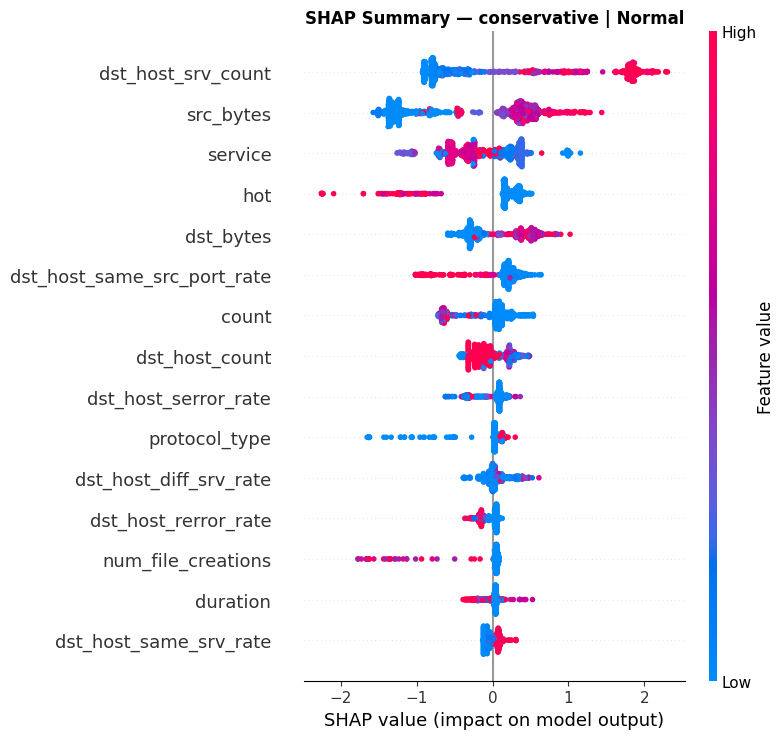

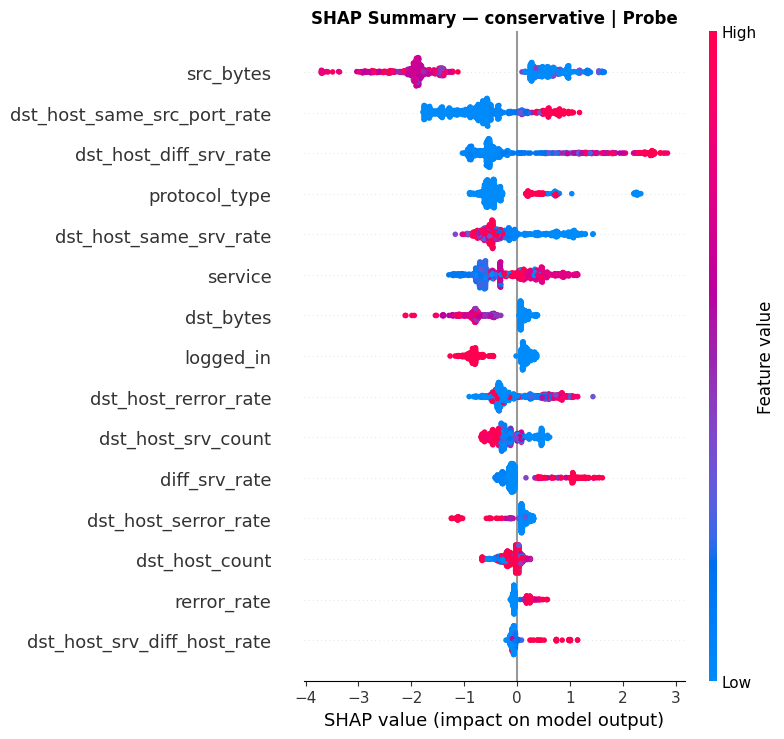

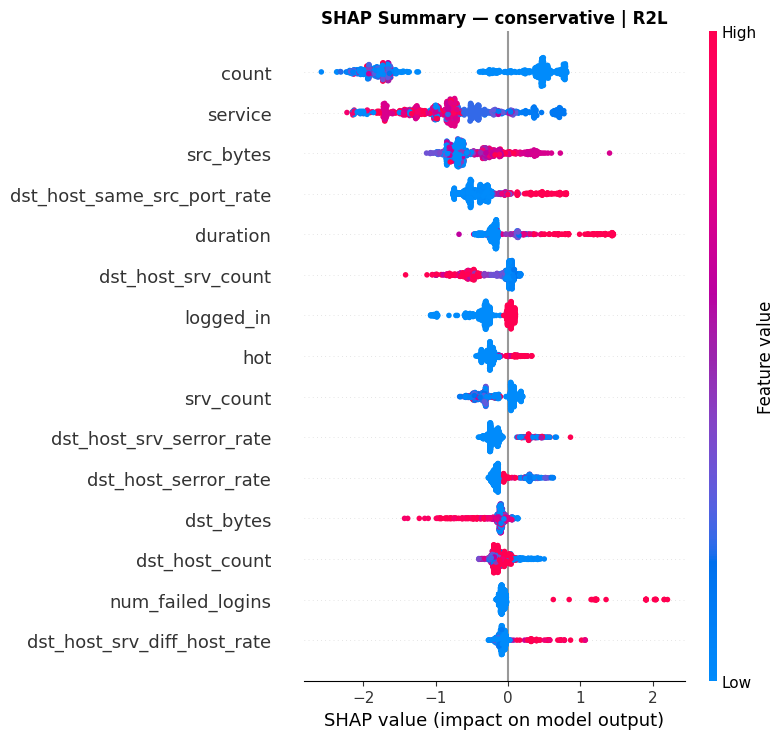

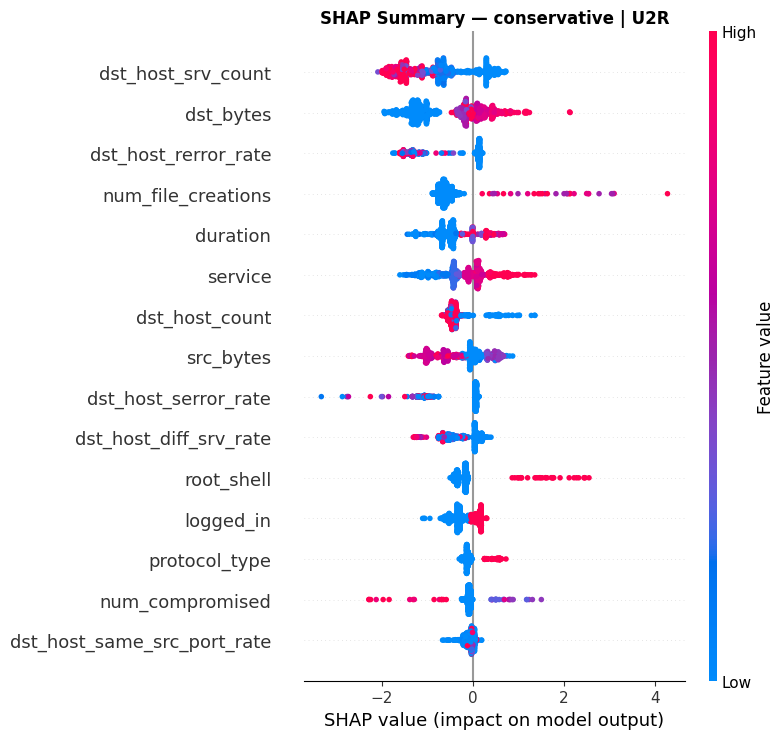

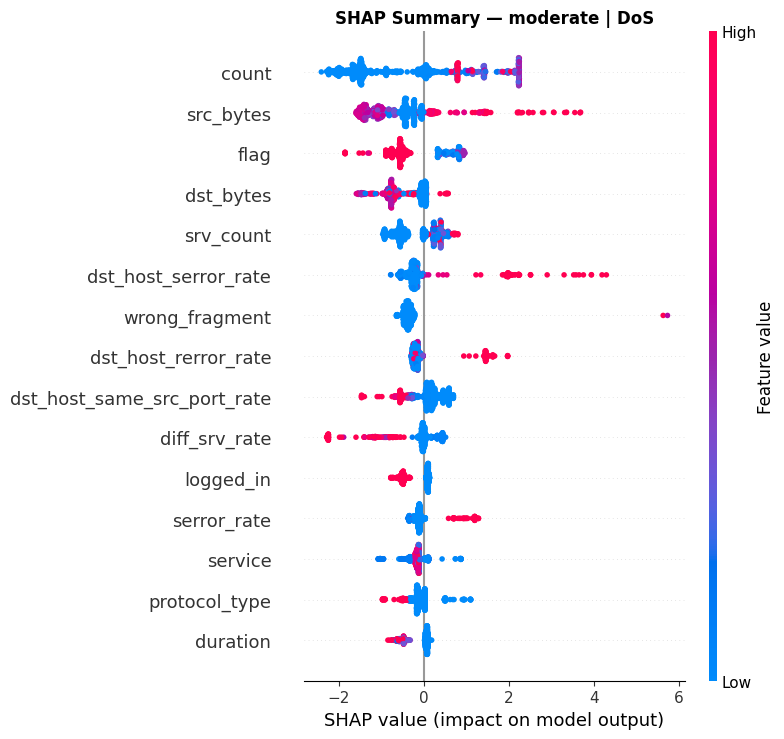

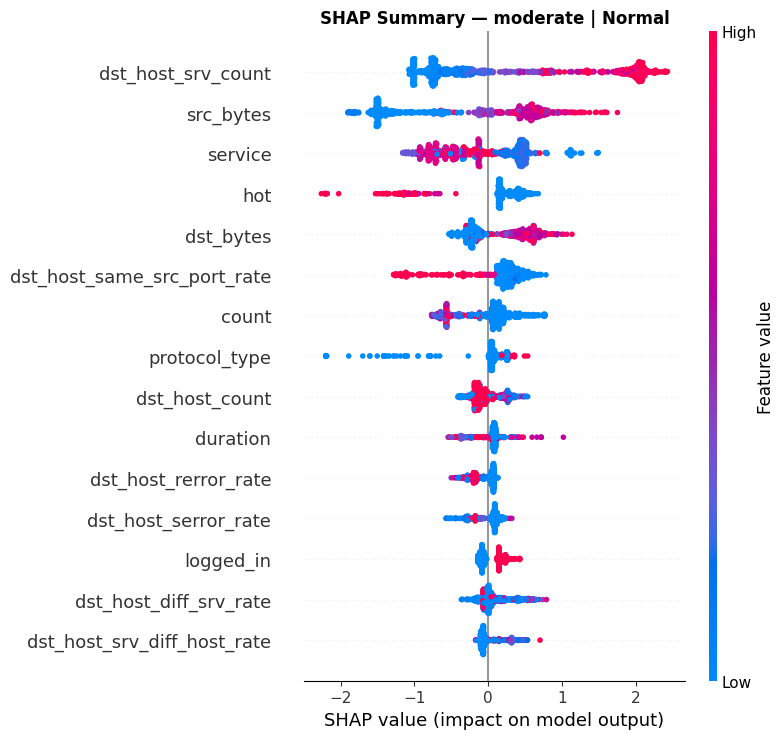

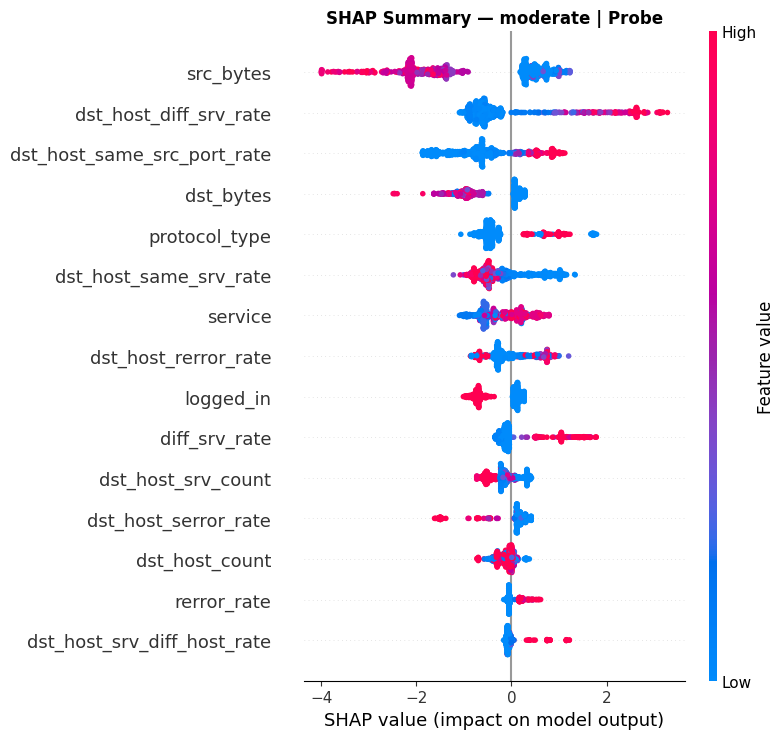

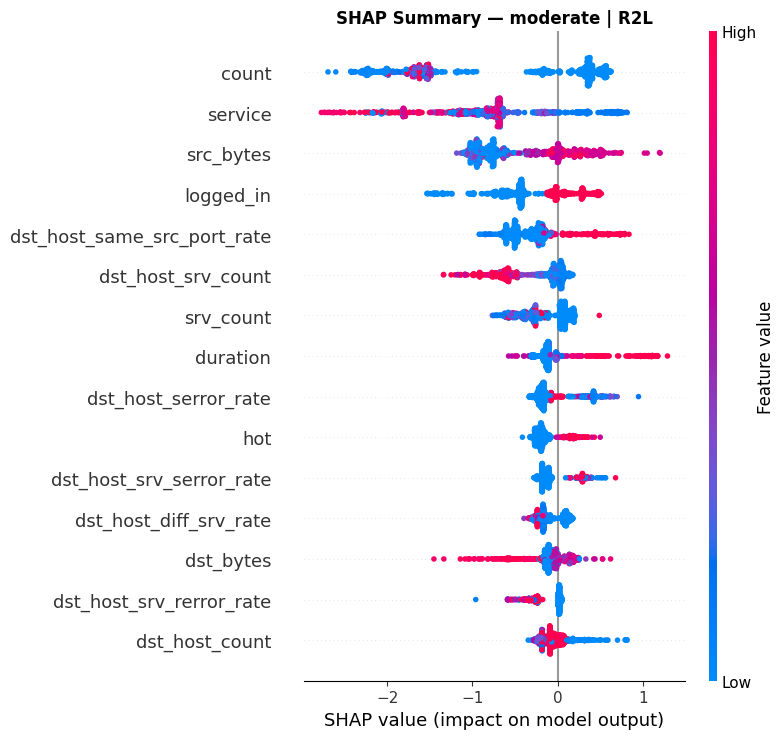

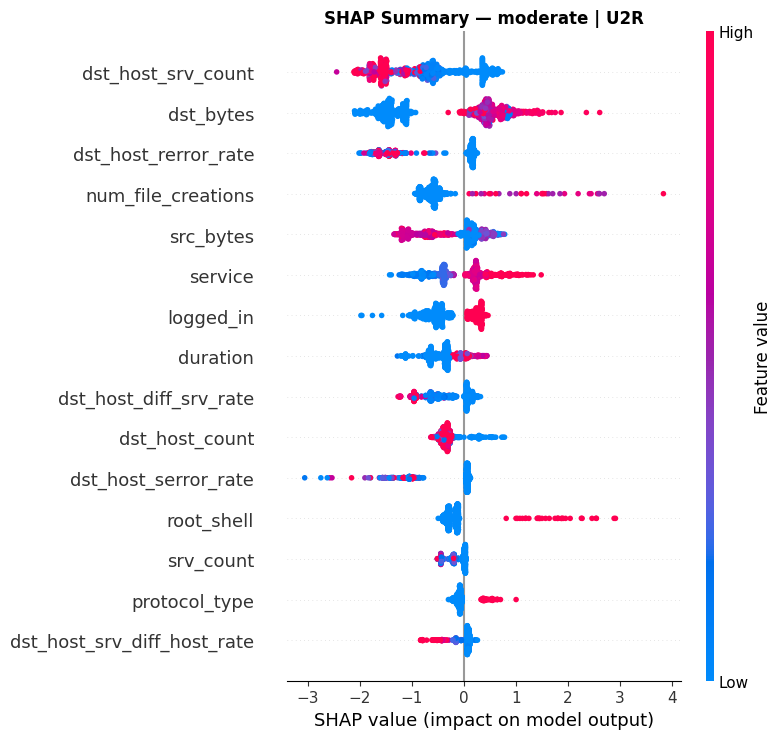

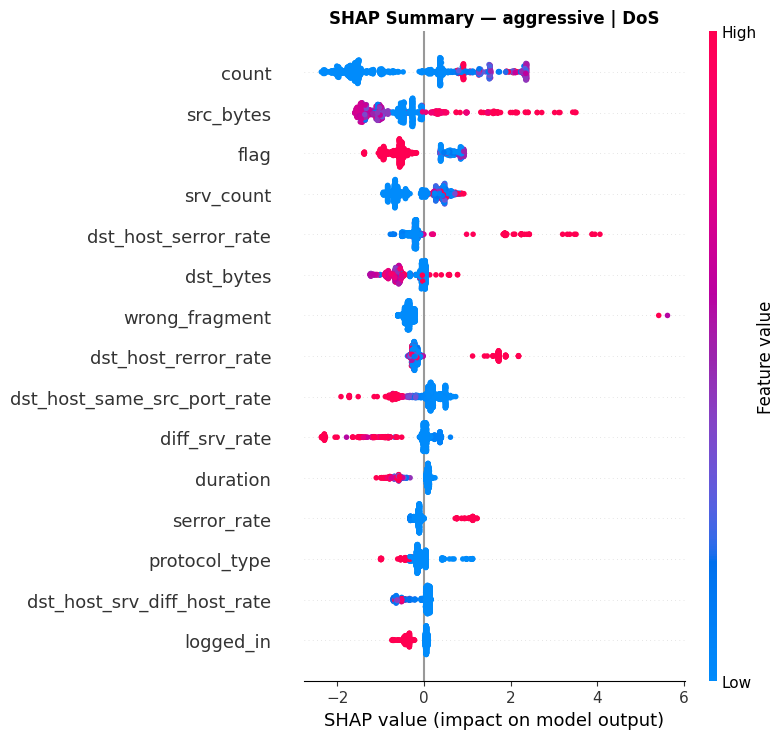

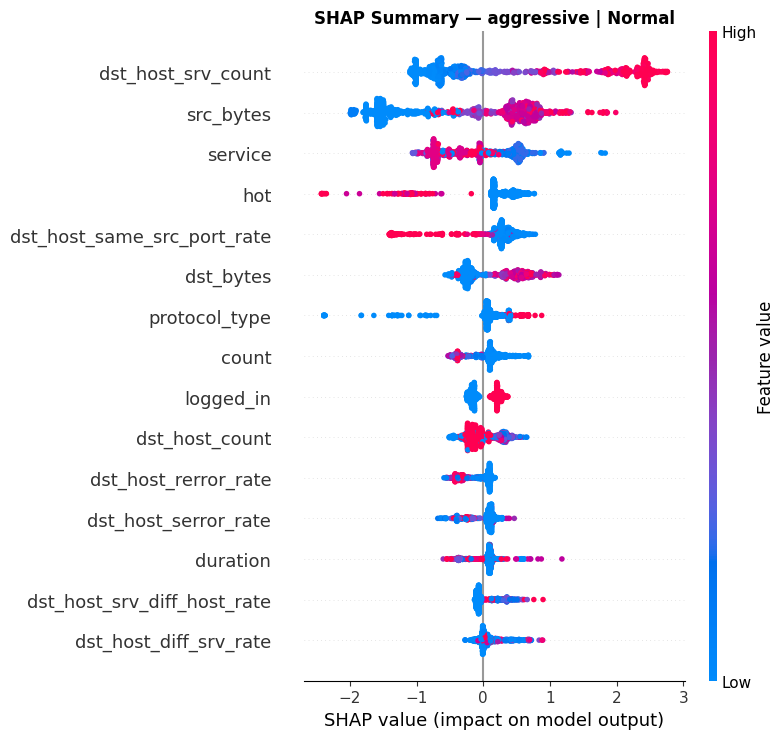

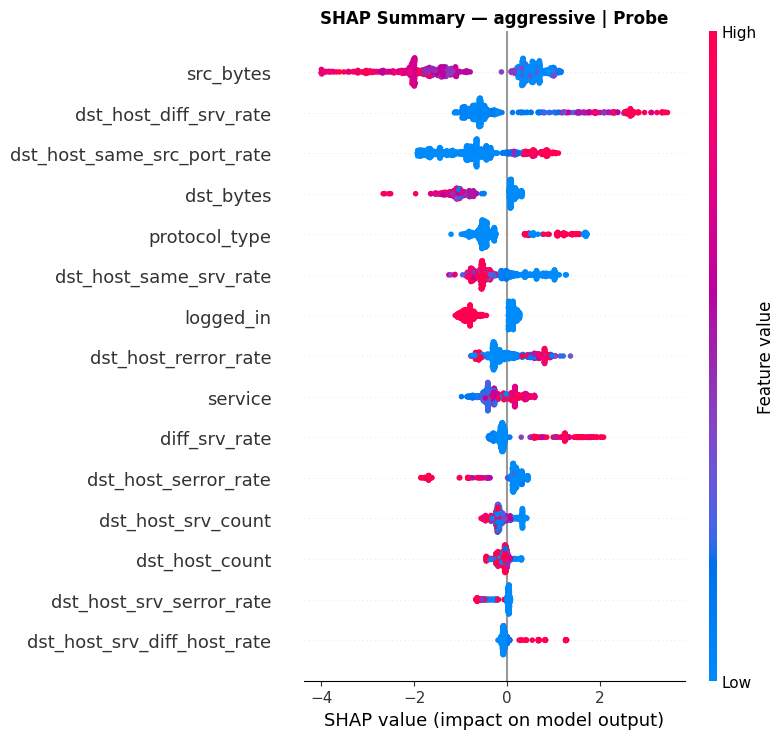

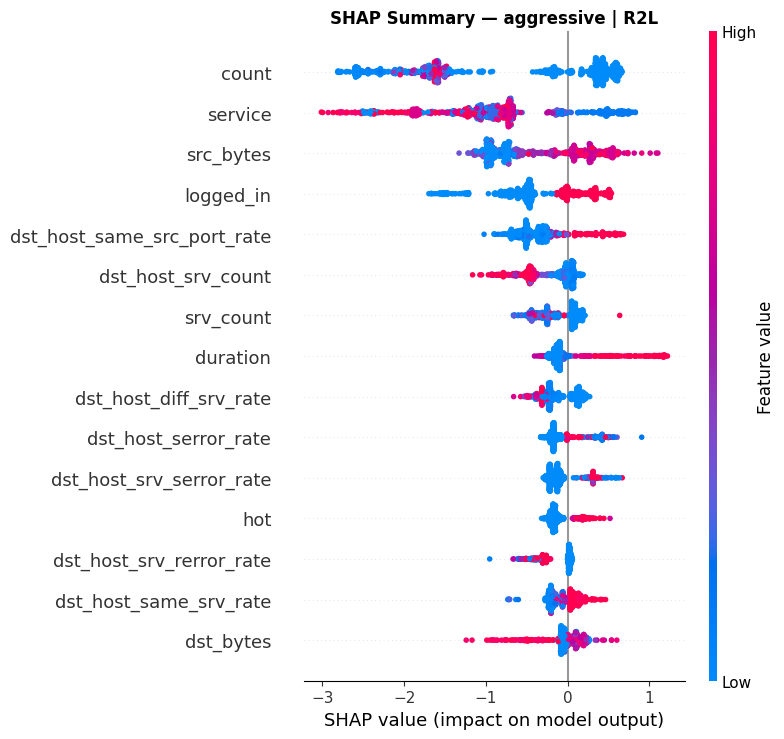

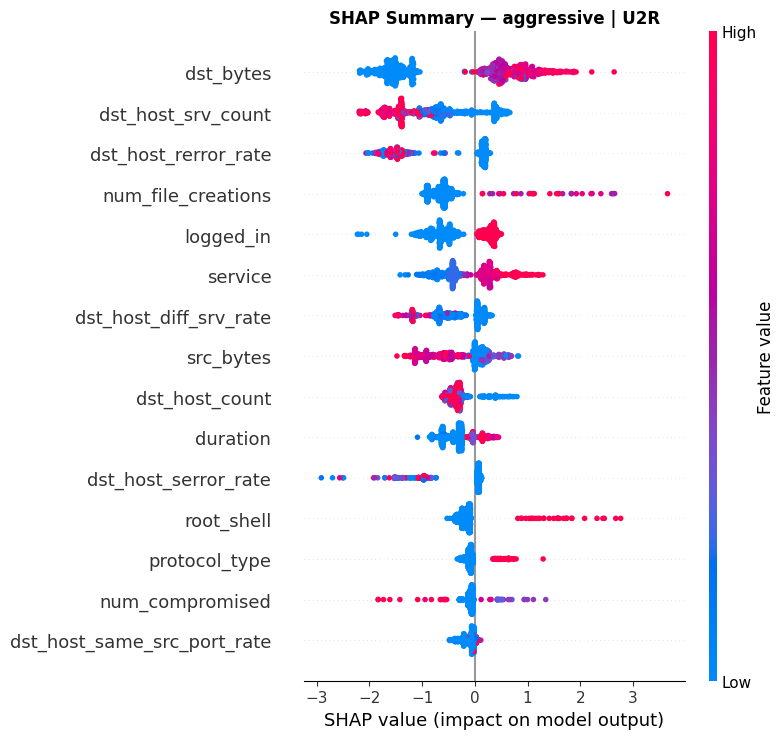

[LIME] Candidates: 4 samples
[LIME] Saved results/xai/lime\lime_baseline_s167_trueR2L_predNormal.html
[LIME] Saved results/xai/lime\lime_aggressive_s167_trueR2L_predR2L.html
[LIME] Saved results/xai/lime\lime_baseline_s246_trueR2L_predNormal.html
[LIME] Saved results/xai/lime\lime_aggressive_s246_trueR2L_predR2L.html
[LIME] Saved results/xai/lime\lime_baseline_s967_trueU2R_predNormal.html
[LIME] Saved results/xai/lime\lime_aggressive_s967_trueU2R_predU2R.html
[LIME] Saved results/xai/lime\lime_baseline_s2153_trueU2R_predNormal.html
[LIME] Saved results/xai/lime\lime_aggressive_s2153_trueU2R_predU2R.html


In [19]:
xai_xgb_params = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "objective": "multi:softprob",
    "num_class": len(np.unique(y_train_res)),
    "eval_metric": "mlogloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

raw_xai_models = {}

log.info("[XAI] Training raw baseline XGB on resampled data...")
baseline_xgb_xai = XGBClassifier(**xai_xgb_params)
baseline_xgb_xai.fit(X_train_res, y_train_res)
raw_xai_models["baseline"] = baseline_xgb_xai

for regime in REGIMES:
    log.info(f"[XAI] Training raw cost-sensitive XGB for regime: {regime}")

    regime_weights = get_sample_weights(y_train_res, regime=regime)

    xgb_model = XGBClassifier(**xai_xgb_params)
    xgb_model.fit(
        X_train_res,
        y_train_res,
        sample_weight=regime_weights,
    )

    raw_xai_models[regime] = xgb_model

xai_results = run_xai_analysis(
    raw_models=raw_xai_models,
    X_test=X_test_scaled,
    y_test=y_test_enc,
    feature_names=features,
    encoder=encoder,
    regimes=REGIMES,
    random_state=RANDOM_STATE,
    n_per_class=200,
    output_dir="results/xai",
    target_classes=("R2L", "U2R"),
)

# Global SHAP — beeswarm + bar for each class
# Uses the stratified sample returned by run_xai_analysis
X_sample_df = xai_results["X_sample"] 

for model_name, shap_vals in xai_results["shap_values_dict"].items():
    for cls_idx in range(len(encoder.classes_)):
        cls_name  = encoder.inverse_transform([cls_idx])[0]
        vals      = shap_vals[:, :, cls_idx] if shap_vals.ndim == 3 else shap_vals[cls_idx]

        # Beeswarm
        fig, ax = plt.subplots(figsize=(11, 6))
        shap.summary_plot(vals, X_sample_df, show=False, max_display=15)
        plt.title(f"SHAP Summary — {model_name} | {cls_name}", fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"results/xai/plots/shap_beeswarm_{model_name}_{cls_name}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

spearman_summary_df = xai_results["spearman_summary_df"]
security_shift_df = xai_results["security_shift_df"]

lime_results = run_lime_analysis(
    raw_models=raw_xai_models,
    X_train=X_train_res,
    X_test=X_test_scaled,
    y_test=y_test_enc,
    feature_names=features,
    encoder=encoder,
    target_model_name="aggressive",
    target_classes=("R2L", "U2R"),
    max_samples_per_class=2,
    num_features=10,
    output_dir="results/xai/lime",
    random_state=RANDOM_STATE
)

lime_candidates_df = lime_results["lime_candidates"]

In [20]:
R2L_IDX = CLASS_TO_IDX["R2L"]
corrected_r2l = Xai.find_corrected_samples(y_test_enc, preds['Cost-Sensitive XGB']['simple_enc'], preds['Cost-Sensitive XGB']['cost_enc'], R2L_IDX)

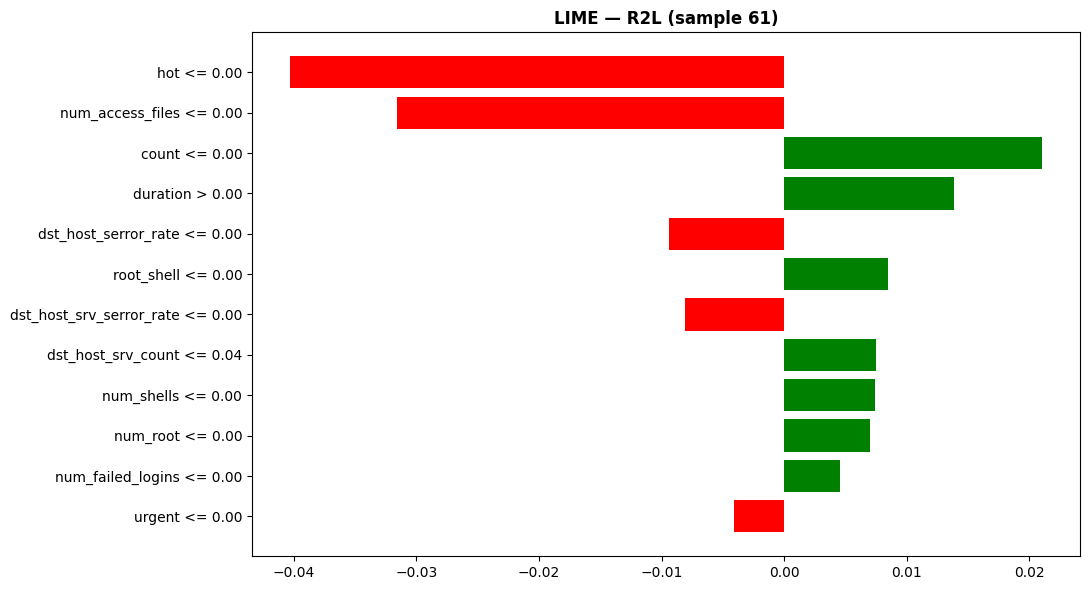

In [21]:
lime_explainer = Xai.build_lime_explainer(
    X_train  = X_train_scaled,
    feature_names = features,
    class_names   = list(encoder.classes_)
)

if len(corrected_r2l) > 0:
    lime_exp = Xai.plot_lime_local(
        lime_explainer = lime_explainer,
        cal_model      = cal_cost_xgb,
        sample_idx     = corrected_r2l[0],
        X_test         = X_test_scaled,
        X_test_human   = X_test_human,
        y_test_enc     = y_test_enc,
        le             = encoder,
        feature_names  = features
    )

[16:13:54] [info]: [XAI] Computing 150 LIME explanations over SHAP sample...
[16:14:28] [success]: [XAI] 150 LIME explanations ready
[16:14:28] [info]: [XAI] Agreement plot for R2L: 34 LIME explanations


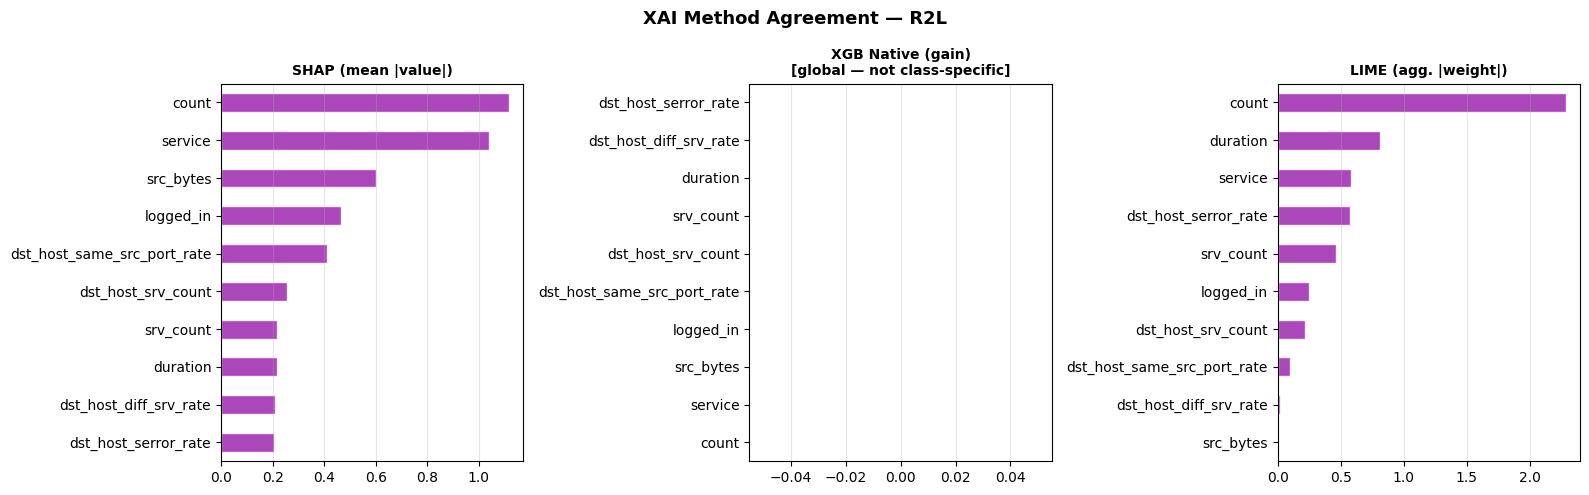

[16:14:29] [info]: [XAI] Agreement plot for U2R: 8 LIME explanations


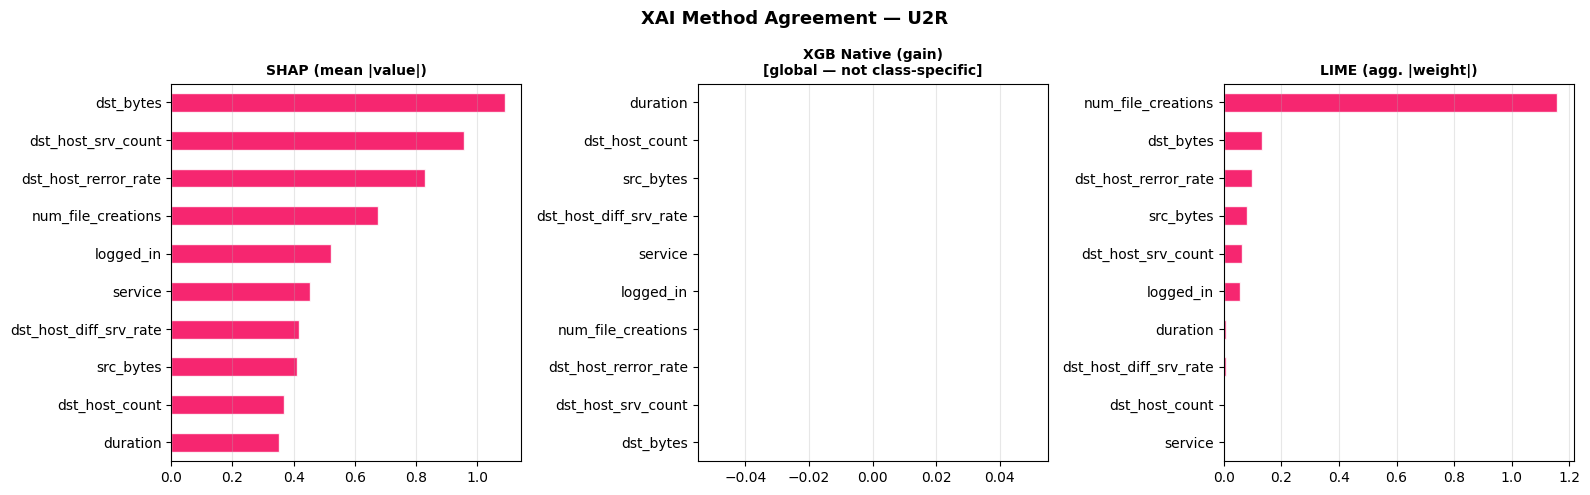

In [22]:
# ── Build LIME explanations over the same stratified sample used by SHAP ─────
# lime_explainer was built in the cell above (using X_train_scaled distribution).
# We iterate over xai_results["X_sample"] (reset-indexed 0..N-1).
# y_lime_sample tracks the true class for class-based filtering below.

X_lime_sample = xai_results["X_sample"]          # DataFrame, index 0..N-1
y_lime_sample = xai_results["y_sample"]           # numpy array, same order

n_lime = min(150, len(X_lime_sample))             # cap for speed (~2 min)
lime_exps   = []
lime_exp_y  = []                                  # true class per explanation

log.info(f"[XAI] Computing {n_lime} LIME explanations over SHAP sample...")
for i in range(n_lime):
    exp = lime_explainer.explain_instance(
        X_lime_sample.iloc[i].values,
        raw_xai_models["aggressive"].predict_proba,
        num_features=15,
        labels=list(range(len(encoder.classes_))),
    )
    lime_exps.append(exp)
    lime_exp_y.append(y_lime_sample[i])

log.success(f"[XAI] {len(lime_exps)} LIME explanations ready")

# ── XAI method agreement: SHAP vs LIME vs XGB native ─────────────────────────
for target_class in ("R2L", "U2R"):
    cls_idx = CLASS_TO_IDX[target_class]

    # Filter to explanations whose true class matches the target
    # Use lime_exp_y (NOT xai_results["X_sample"].index — that's reset to 0..N-1)
    target_lime_exps = [
        lime_exps[i]
        for i, cls in enumerate(lime_exp_y)
        if cls == cls_idx
    ]

    if not target_lime_exps:
        log.info(f"[XAI] No LIME explanations for {target_class} in sample — skipping.")
        continue

    log.info(f"[XAI] Agreement plot for {target_class}: {len(target_lime_exps)} LIME explanations")
    Xai.plot_xai_agreement(
        shap_values      = xai_results["shap_values_dict"]["aggressive"],
        lime_exp_list    = target_lime_exps,
        baseline_model   = raw_xai_models["aggressive"],
        feature_names    = features,
        le               = encoder,
        target_class_idx = cls_idx,
    )

[16:14:31] [info]: SHAP beeswarm — baseline | R2L + U2R only


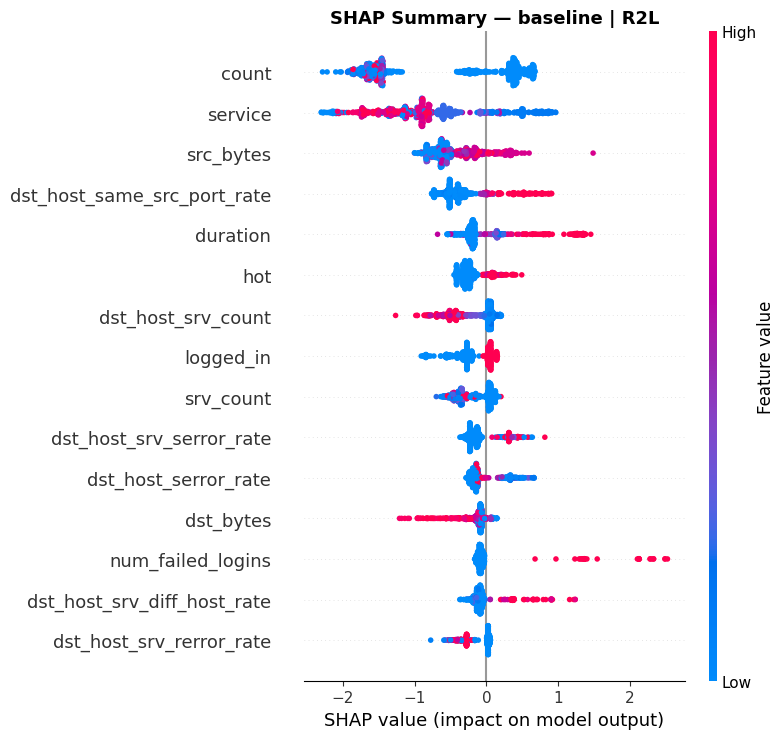

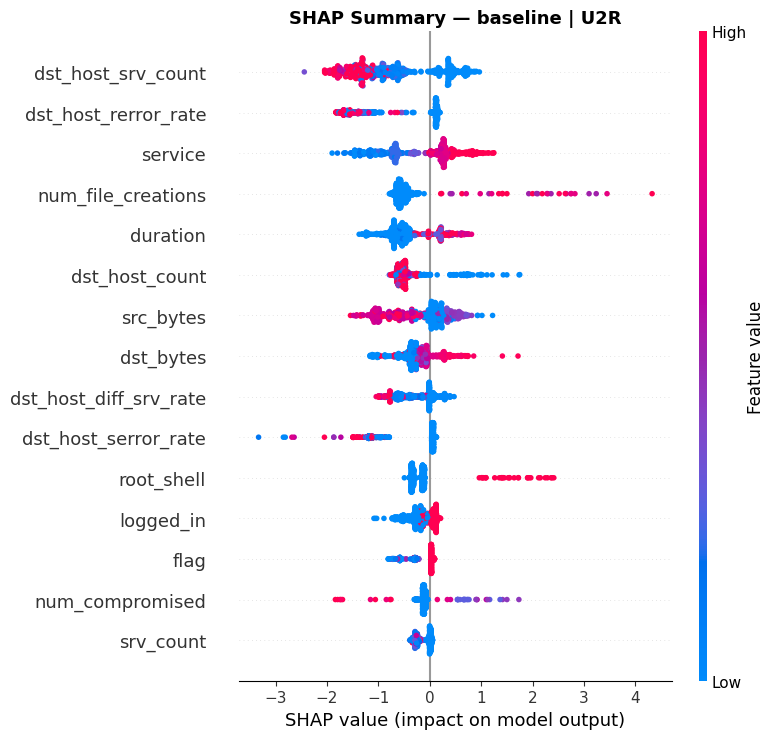

[16:14:33] [info]: SHAP beeswarm — conservative | R2L + U2R only


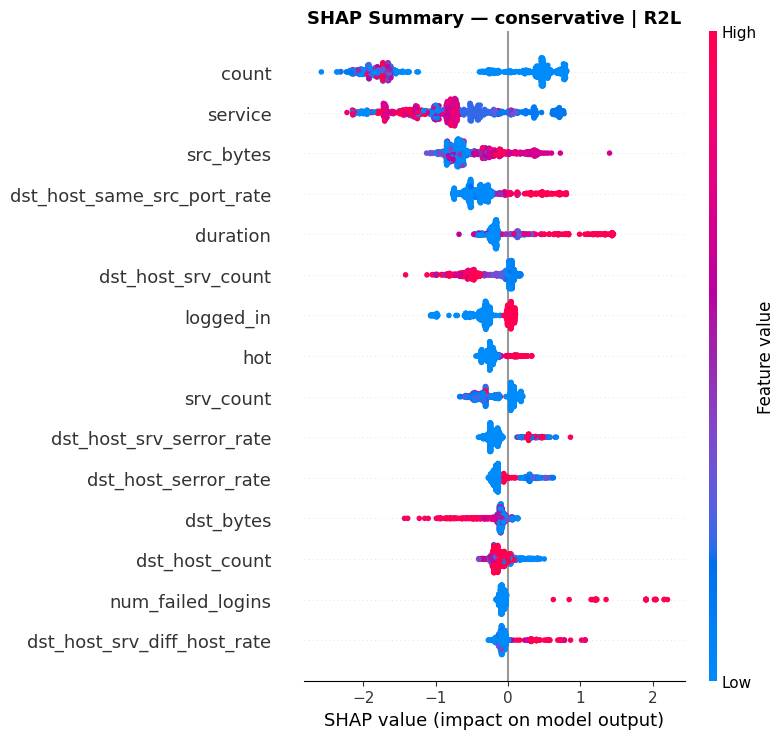

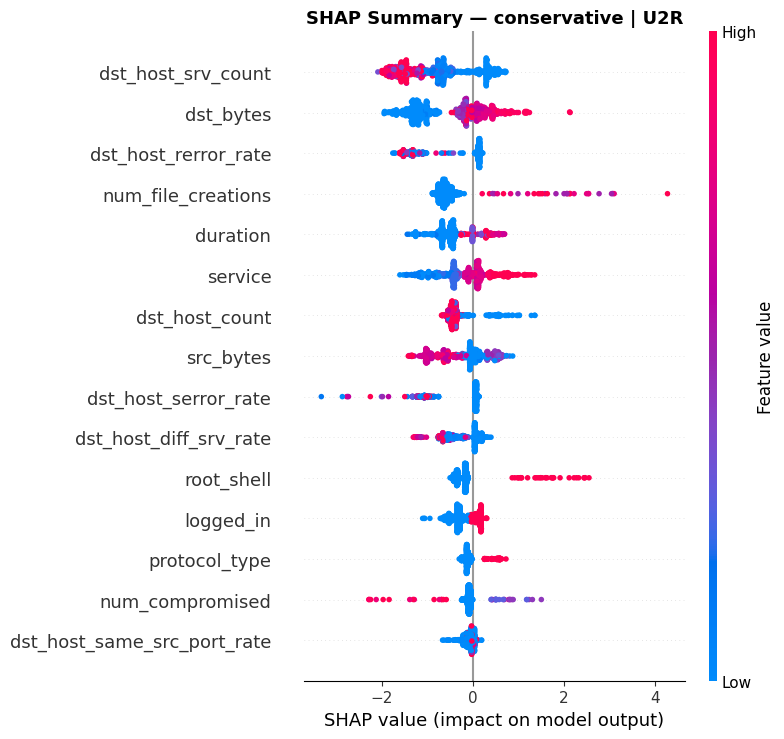

[16:14:36] [info]: SHAP beeswarm — moderate | R2L + U2R only


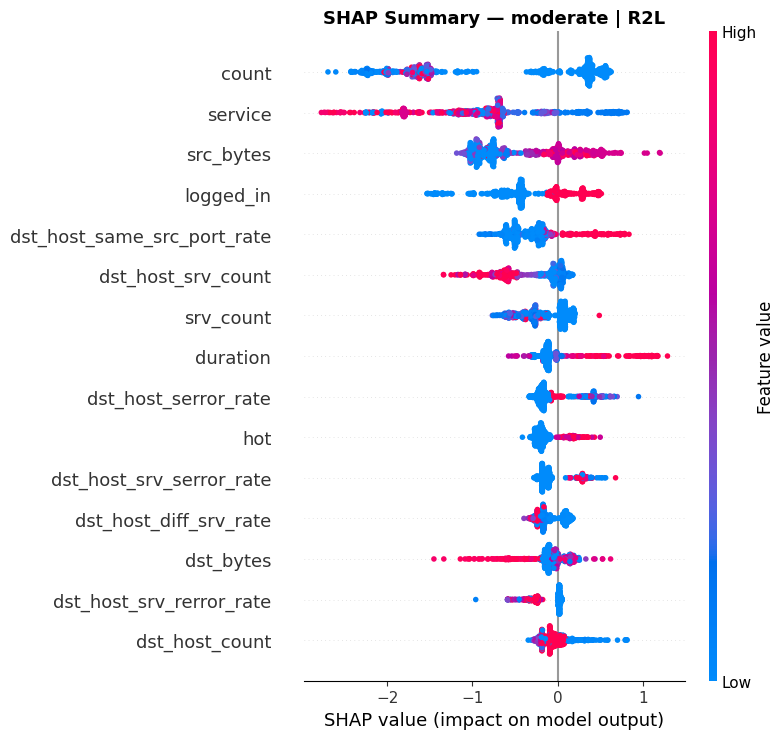

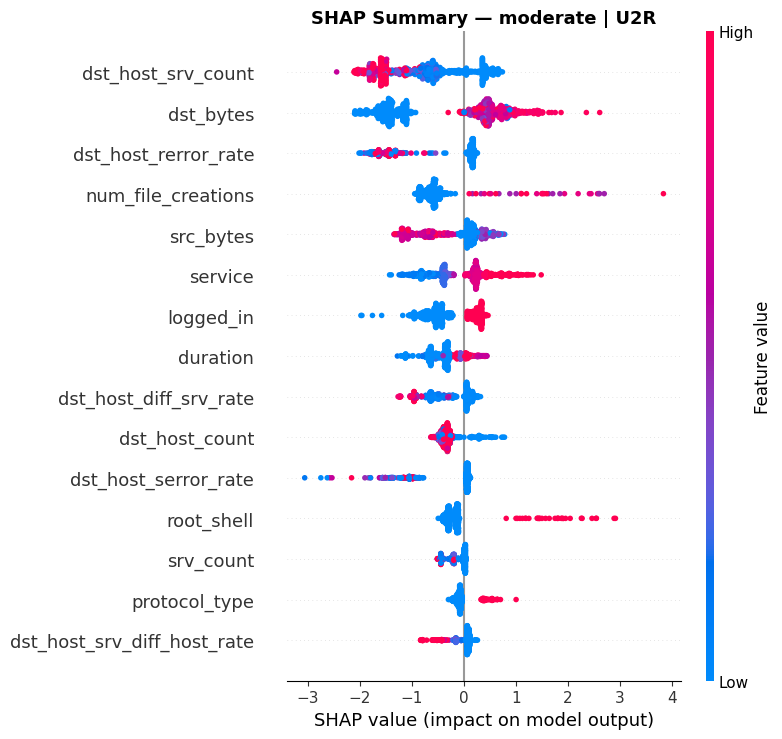

[16:14:38] [info]: SHAP beeswarm — aggressive | R2L + U2R only


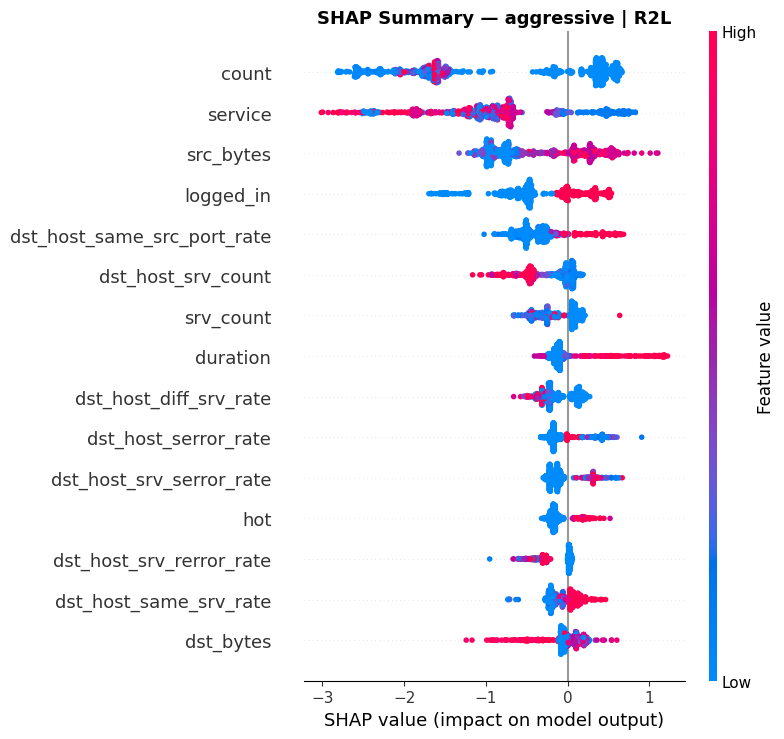

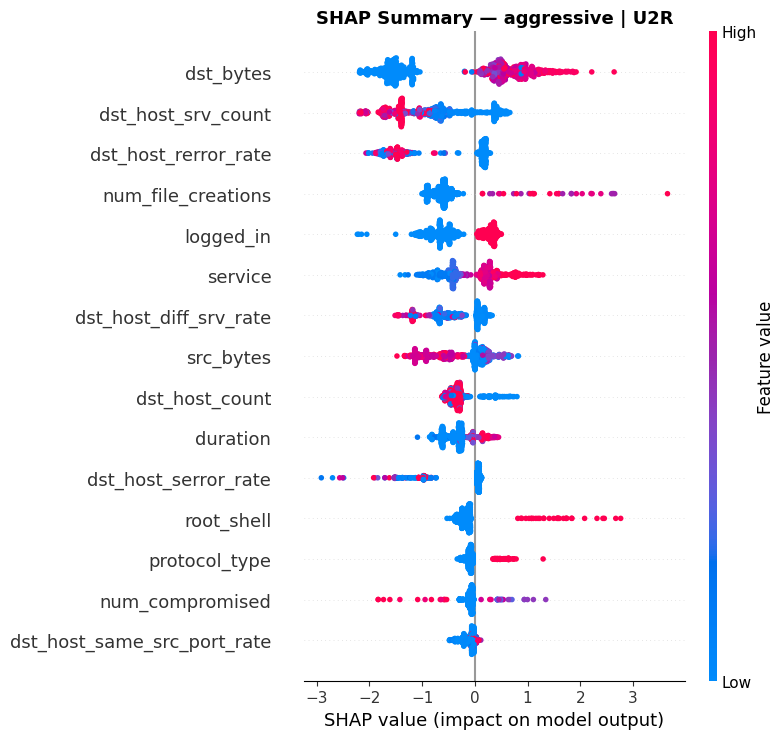

In [23]:
from Xai import plot_shap_global
import numpy as np

FOCUS_CLASSES = ("R2L", "U2R")
focus_idxs    = [encoder.transform([c])[0] for c in FOCUS_CLASSES]

for model_name, shap_vals in xai_results["shap_values_dict"].items():
    # Slice to only the focus classes along axis 2
    shap_focus = shap_vals[:, :, focus_idxs]  # shape: (n_samples, n_features, 2)

    log.info(f"SHAP beeswarm — {model_name} | R2L + U2R only")
    for i, cls_name in enumerate(FOCUS_CLASSES):
        cls_idx = encoder.transform([cls_name])[0]
        vals    = shap_vals[:, :, cls_idx]

        import matplotlib.pyplot as plt
        import shap

        fig, ax = plt.subplots(figsize=(11, 7))
        shap.summary_plot(
            vals,
            xai_results["X_sample"],
            feature_names=features,
            show=False,
            max_display=15,
        )
        plt.title(f"SHAP Summary — {model_name} | {cls_name}",
                  fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"results/xai/plots/shap_beeswarm_{model_name}_{cls_name}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

## XGBoost Native Importance + XAI Agreement

### XGBoost Native Importance: Baseline vs Aggressive

Shows gain/cover/weight for the two extreme models.
Architecturally grounded, no approximation, unlike SHAP.

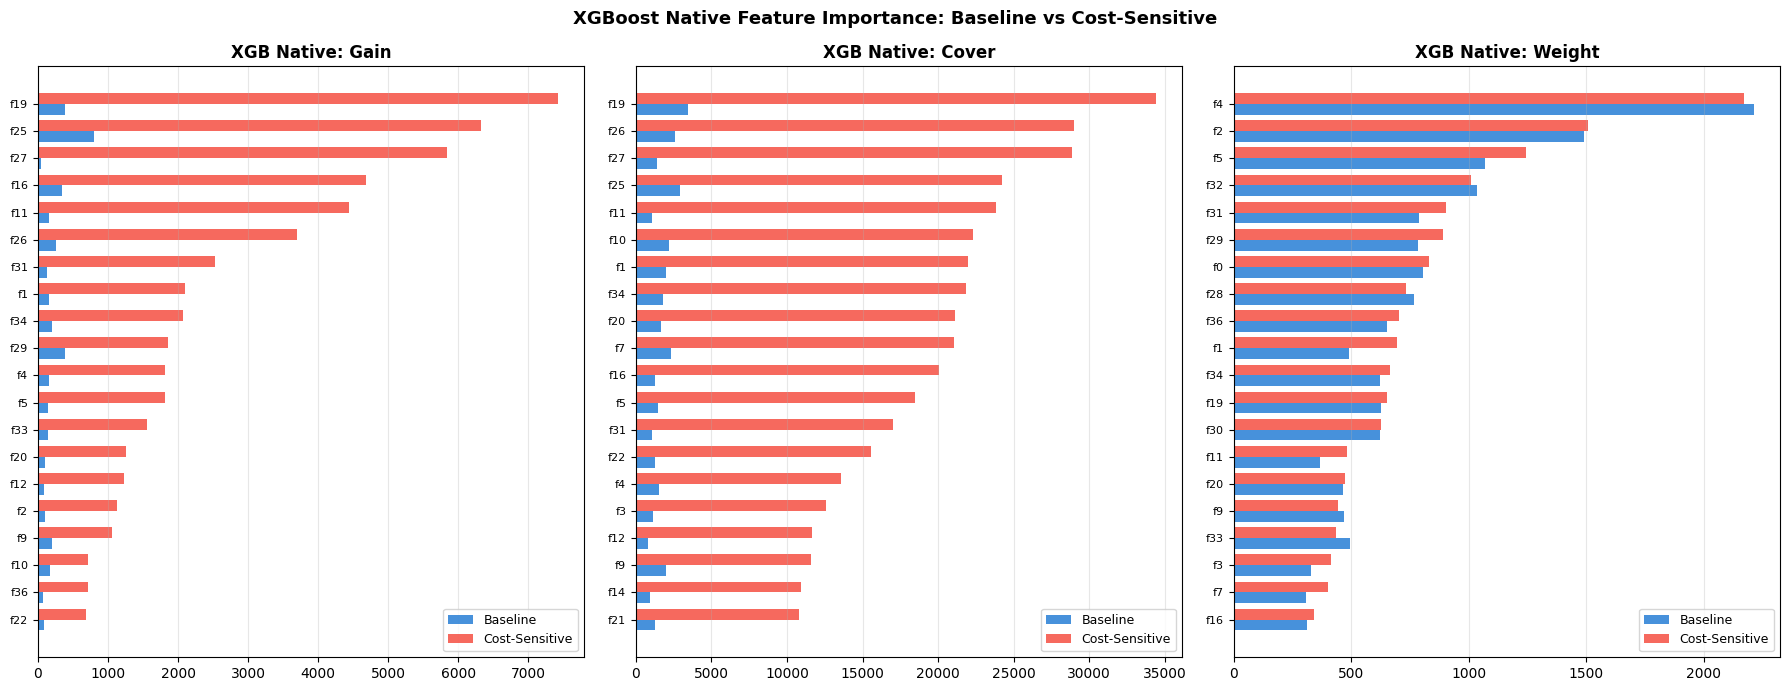

In [24]:
plot_xgb_native_importance(
    baseline_model = raw_xai_models["baseline"],
    costsens_model = raw_xai_models["aggressive"],
    feature_names  = features,
    top_n          = 20,
    save           = True,
)

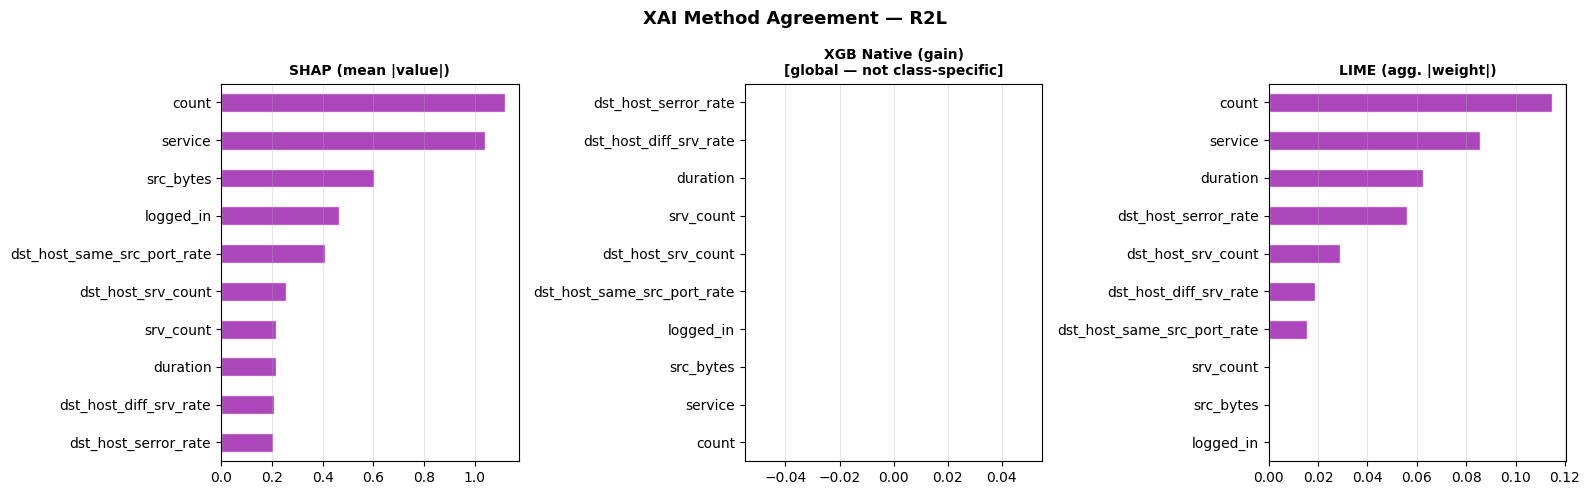

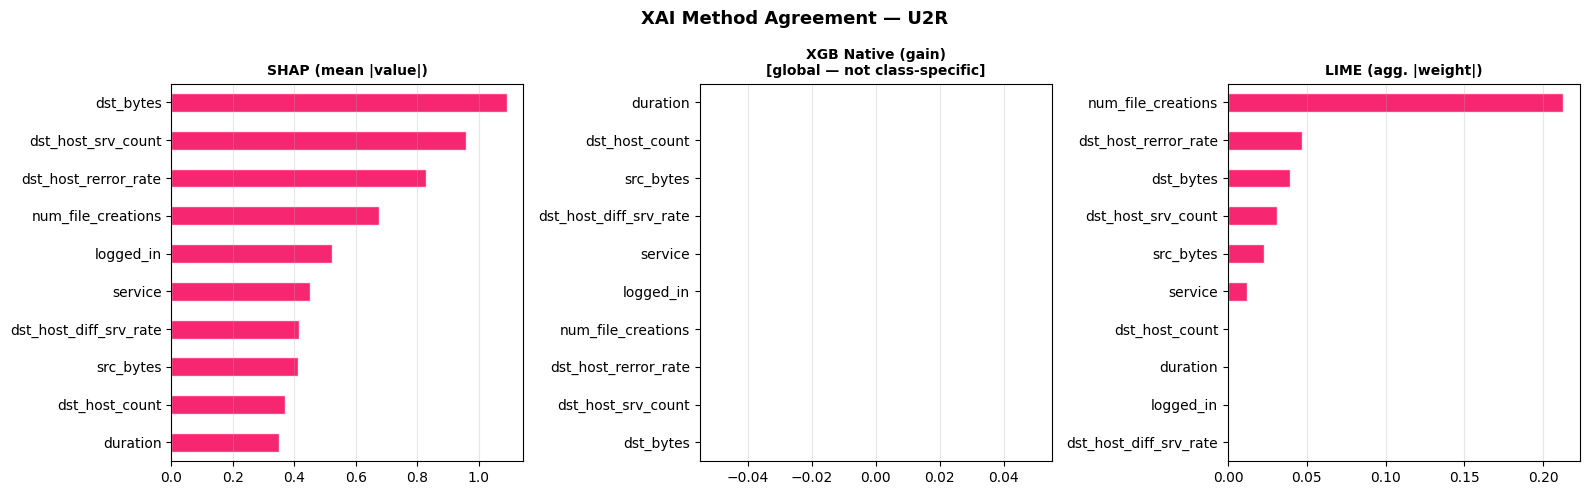

In [25]:
# ── XAI Method Agreement ─────────────────────────────────────────────────────
# Compares top features from SHAP, XGB native gain, and LIME side-by-side.
# Agreement across methods strengthens the interpretation.
# Uses the aggressive model as the cost-sensitive representative.

from Xai import plot_xai_agreement
from Costs import CLASS_TO_IDX

for target_class in ("R2L", "U2R"):
    cls_idx = CLASS_TO_IDX[target_class]

    # Filter LIME explanations to samples whose true class is the target
    # lime_results["lime_explanations"] contains one row per (sample, model) pair
    if lime_results and "lime_explanations" in lime_results:
        lime_exp_df = lime_results["lime_explanations"]

        # Rebuild explanation objects for samples matching this class
        # We need the raw LIME Explanation objects, not just the index CSV.
        # run_lime_analysis saves HTML only; rebuild inline for the agreement plot.
        target_lime_exps = []
        if "lime_candidates" in lime_results:
            candidates = lime_results["lime_candidates"]
            target_candidates = candidates[candidates["true_class"] == target_class]

            if not target_candidates.empty:
                import numpy as np
                from lime.lime_tabular import LimeTabularExplainer

                explainer_temp = LimeTabularExplainer(
                    training_data  = X_train_res,
                    feature_names  = features,
                    class_names    = list(encoder.classes_),
                    mode           = "classification",
                    random_state   = RANDOM_STATE,
                )
                for _, cand_row in target_candidates.iterrows():
                    sidx = int(cand_row["sample_index"])
                    exp  = explainer_temp.explain_instance(
                        X_test_scaled[sidx],
                        raw_xai_models["aggressive"].predict_proba,
                        num_features = 15,
                        labels       = list(range(len(encoder.classes_))),
                    )
                    target_lime_exps.append(exp)

    if not target_lime_exps:
        log.info(f"No LIME explanations available for {target_class} — skipping agreement plot.")
        continue

    plot_xai_agreement(
        shap_values      = xai_results["shap_values_dict"]["aggressive"],
        lime_exp_list    = target_lime_exps,
        baseline_model   = raw_xai_models["aggressive"],
        feature_names    = features,
        le               = encoder,
        target_class_idx = cls_idx,
        top_n            = 10,
        save             = True,
    )

In [26]:
# ── Spearman Rank Correlation — Attentional Shift ────────────────────────────
# Quantifies whether cost-sensitive training produced genuinely different
# decision logic vs the baseline.
#
# Reading guide:
#   "Global" row  →  sanity check only (aggregated across all 5 classes,
#                    dominated by Normal + DoS which have many samples).
#   R2L / U2R rows  →  PRIMARY FINDINGS: these are the high-cost minority
#                       classes where attentional shift matters.
#   ρ < 0.50  →  strong shift ✓
#   ρ < 0.75  →  moderate shift
#   ρ ≥ 0.75  →  similar ranking to baseline

spearman_summary_df = xai_results["spearman_summary_df"]
security_shift_df   = xai_results["security_shift_df"]

global_rows = spearman_summary_df[spearman_summary_df["class"] == "Global"]
class_rows  = spearman_summary_df[spearman_summary_df["class"] != "Global"]

log.info("Spearman ρ — Sanity Check (Global, aggregated across all classes):")
display(global_rows.reset_index(drop=True))

log.info("Spearman ρ — PRIMARY FINDINGS (class-specific, R2L and U2R):")
log.info("  Low ρ = cost-sensitive model uses genuinely different features for these classes.")
display(class_rows.reset_index(drop=True))

log.info("Security-Critical Feature Shift (rank change vs baseline):")
log.info("  Positive rank_change = feature moved UP in importance after cost-sensitive training.")
display(security_shift_df)

[16:14:48] [info]: Spearman ρ — Sanity Check (Global, aggregated across all classes):


,class,comparison,spearman_rho,p_value
0,Global,baseline_vs_conservative,0.995623,1.161168e-38
1,Global,baseline_vs_moderate,0.991027,4.574500e-33
2,Global,baseline_vs_aggressive,0.986213,1.003320e-29


[16:14:48] [info]: Spearman ρ — PRIMARY FINDINGS (class-specific, R2L and U2R):
[16:14:48] [info]:   Low ρ = cost-sensitive model uses genuinely different features for these classes.


,class,comparison,spearman_rho,p_value
0,R2L,baseline_vs_conservative,0.992778,9.324602e-35
1,R2L,baseline_vs_moderate,0.969362,1.527865e-23
2,R2L,baseline_vs_aggressive,0.947040,2.414842e-19
3,U2R,baseline_vs_conservative,0.937849,3.989700e-18
4,U2R,baseline_vs_moderate,0.913557,1.236111e-15
5,U2R,baseline_vs_aggressive,0.895612,3.170014e-14


[16:14:48] [info]: Security-Critical Feature Shift (rank change vs baseline):
[16:14:48] [info]:   Positive rank_change = feature moved UP in importance after cost-sensitive training.


,feature,baseline_rank,baseline_importance,conservative_rank,conservative_importance,moderate_rank,moderate_importance,aggressive_rank,aggressive_importance,conservative_rank_change,conservative_importance_change,moderate_rank_change,moderate_importance_change,aggressive_rank_change,aggressive_importance_change
0,root_shell,25,0.062222,24,0.069269,24,0.062964,24,0.057831,1,0.007046,1,0.000742,1,-0.004391
1,su_attempted,37,0.000477,37,0.000532,37,0.000343,37,0.000547,0,0.000055,0,-0.000134,0,0.000070
2,num_failed_logins,28,0.039234,28,0.035519,32,0.026724,32,0.026300,0,-0.003715,-4,-0.012510,-4,-0.012933
3,num_shells,35,0.007334,35,0.006983,35,0.007600,36,0.007178,0,-0.000350,0,0.000266,-1,-0.000156
4,num_access_files,31,0.017469,31,0.021100,30,0.027088,30,0.029957,0,0.003631,1,0.009620,1,0.012488
5,logged_in,10,0.223341,9,0.249959,9,0.323533,9,0.353094,1,0.026618,1,0.100192,1,0.129753
6,num_compromised,27,0.052476,27,0.047743,28,0.038318,28,0.036301,0,-0.004733,-1,-0.014158,-1,-0.016175
7,num_root,34,0.008251,34,0.007946,34,0.009694,34,0.011203,0,-0.000305,0,0.001443,0,0.002952
8,num_file_creations,18,0.139523,16,0.149984,17,0.149953,16,0.153963,2,0.010461,1,0.010429,2,0.014439


# Evaluation

We use 4 metrics for every model:

1. Classification report: precision / recall / F1 per class
2. Total Economic Loss (TEL): our primary metric grounded in dollar values
3. Cost-ROC curves: recall vs FPR for R2L and U2R specifically
4. Spearman ρ: quantitative attentional shift between baseline and cost-sensitive SHAP

Finally we do an ablation study across all three cost regimes

## Classification Reports

In [27]:
for name, (cal_model, _) in MODELS.items():
    y_pred = encoder.inverse_transform(preds[name]["cost_enc"])
    show_classification_report(y_test_raw, y_pred, encoder, title=name)
    show_confusion_matrix(y_test_enc, preds[name]['cost_enc'], encoder)

[16:14:48] [info]: BASELINE RF
[16:14:48] [info]:               precision    recall  f1-score   support

         DoS       0.96      0.82      0.89      7460
      Normal       0.69      0.97      0.80      9711
       Probe       0.85      0.79      0.82      2421
         R2L       0.98      0.06      0.12      2885
         U2R       0.60      0.09      0.16        67

    accuracy                           0.78     22544
   macro avg       0.81      0.55      0.56     22544
weighted avg       0.83      0.78      0.74     22544

[16:14:48] [info]: Confusion Matrix: 
[16:14:48] [info]:               DoS  Normal  Probe  R2L  U2R
True \ Pred                               
DoS          6154    1200    106    0    0
Normal         81    9413    215    0    2
Probe         166     352   1903    0    0
R2L             0    2677     24  182    2
U2R             0      57      0    4    6
[16:14:48] [info]: COST-SENSITIVE RF
[16:14:48] [info]:               precision    recall  f1-score   s

## Total Economic Loss


──────────────────────────────────────────────────
  Total Economic Loss — Baseline RF [moderate]
──────────────────────────────────────────────────
  TEL (total):     $4,093,873,725.00
  TEL from FN:     $4,093,870,000.00
  TEL from FP:     $       3,725.00

  FN breakdown:
    U2R     :     $ 179,550,000.00
    R2L     :     $3,212,400,000.00
    DoS     :     $ 672,000,000.00
    Probe   :     $  29,920,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Cost-Sensitive RF [moderate]
──────────────────────────────────────────────────
  TEL (total):     $3,908,598,750.00
  TEL from FN:     $3,908,595,000.00
  TEL from FP:     $       3,750.00

  FN breakdown:
    U2R     :     $ 132,300,000.00
    R2L     :     $3,068,400,000.00
    DoS     :     $ 677,040,000.00
    Probe   :     $  30,855,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Baseline XGB [moderate]
──────────────────────────────────────────────────
  TEL (

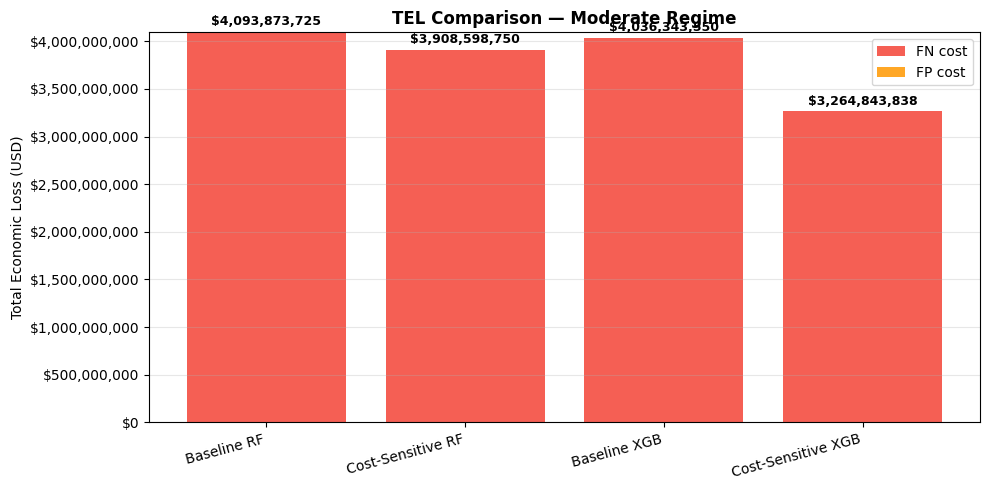

In [28]:
tel_results = {}
for name in MODELS:
    tel_results[name] = report_tel(y_test_enc, preds[name]['cost_enc'], name)

compare_tel(tel_results)

## Cost-ROC Curves

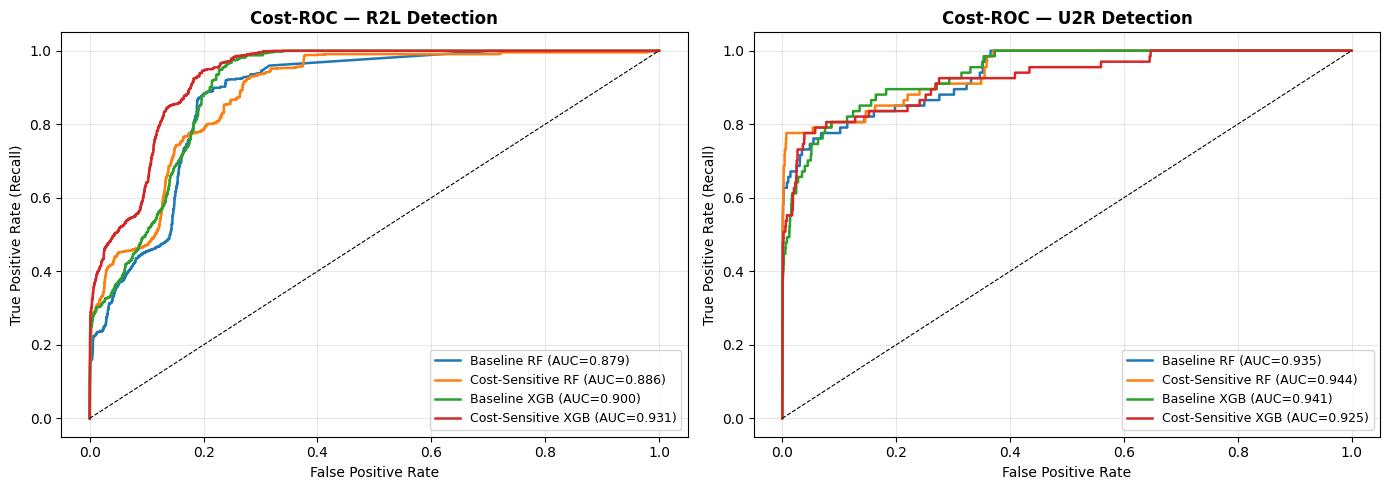

In [29]:
plot_cost_roc(models= {name: cal for name, (cal, _) in MODELS.items()}, X_test=X_test_scaled,  y_test_enc=y_test_enc, le=encoder, focus_classes=('R2L', 'U2R'))

## Spearman Rank Correlation

In [30]:
log.info("SHAP Spearman Rank Correlation Summary:")
global_rows = spearman_summary_df[spearman_summary_df['class'] == 'Global']
class_rows = spearman_summary_df[spearman_summary_df['class'] != 'Global']

log.info("Sanity Check (Global): ")
display(global_rows.reset_index(drop=True))

log.info("Primary Findings")
display(class_rows.reset_index(drop=True))
# display(spearman_summary_df)

log.info("Security-Critical Feature Shift Summary:")
display(security_shift_df)

[16:14:54] [info]: SHAP Spearman Rank Correlation Summary:
[16:14:54] [info]: Sanity Check (Global): 


,class,comparison,spearman_rho,p_value
0,Global,baseline_vs_conservative,0.995623,1.161168e-38
1,Global,baseline_vs_moderate,0.991027,4.574500e-33
2,Global,baseline_vs_aggressive,0.986213,1.003320e-29


[16:14:54] [info]: Primary Findings


,class,comparison,spearman_rho,p_value
0,R2L,baseline_vs_conservative,0.992778,9.324602e-35
1,R2L,baseline_vs_moderate,0.969362,1.527865e-23
2,R2L,baseline_vs_aggressive,0.947040,2.414842e-19
3,U2R,baseline_vs_conservative,0.937849,3.989700e-18
4,U2R,baseline_vs_moderate,0.913557,1.236111e-15
5,U2R,baseline_vs_aggressive,0.895612,3.170014e-14


[16:14:54] [info]: Security-Critical Feature Shift Summary:


,feature,baseline_rank,baseline_importance,conservative_rank,conservative_importance,moderate_rank,moderate_importance,aggressive_rank,aggressive_importance,conservative_rank_change,conservative_importance_change,moderate_rank_change,moderate_importance_change,aggressive_rank_change,aggressive_importance_change
0,root_shell,25,0.062222,24,0.069269,24,0.062964,24,0.057831,1,0.007046,1,0.000742,1,-0.004391
1,su_attempted,37,0.000477,37,0.000532,37,0.000343,37,0.000547,0,0.000055,0,-0.000134,0,0.000070
2,num_failed_logins,28,0.039234,28,0.035519,32,0.026724,32,0.026300,0,-0.003715,-4,-0.012510,-4,-0.012933
3,num_shells,35,0.007334,35,0.006983,35,0.007600,36,0.007178,0,-0.000350,0,0.000266,-1,-0.000156
4,num_access_files,31,0.017469,31,0.021100,30,0.027088,30,0.029957,0,0.003631,1,0.009620,1,0.012488
5,logged_in,10,0.223341,9,0.249959,9,0.323533,9,0.353094,1,0.026618,1,0.100192,1,0.129753
6,num_compromised,27,0.052476,27,0.047743,28,0.038318,28,0.036301,0,-0.004733,-1,-0.014158,-1,-0.016175
7,num_root,34,0.008251,34,0.007946,34,0.009694,34,0.011203,0,-0.000305,0,0.001443,0,0.002952
8,num_file_creations,18,0.139523,16,0.149984,17,0.149953,16,0.153963,2,0.010461,1,0.010429,2,0.014439


## Ablation Study

### Inference Only
Here we reevaluate cost-sensitive XGB predictions under each regime's cost matrix. Models are not retrained, we only infer cost matrix changes.


──────────────────────────────────────────────────
  Total Economic Loss — Cost XGB [conservative] [conservative]
──────────────────────────────────────────────────
  TEL (total):     $3,348,358,775.00
  TEL from FN:     $3,348,355,000.00
  TEL from FP:     $       3,775.00

  FN breakdown:
    U2R     :     $ 116,550,000.00
    R2L     :     $2,625,600,000.00
    DoS     :     $ 570,080,000.00
    Probe   :     $  36,125,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Cost XGB [moderate] [moderate]
──────────────────────────────────────────────────
  TEL (total):     $3,264,843,837.50
  TEL from FN:     $3,264,840,000.00
  TEL from FP:     $       3,837.50

  FN breakdown:
    U2R     :     $ 110,250,000.00
    R2L     :     $2,582,400,000.00
    DoS     :     $ 540,400,000.00
    Probe   :     $  31,790,000.00

──────────────────────────────────────────────────
  Total Economic Loss — Cost XGB [aggressive] [aggressive]
─────────────────────────────

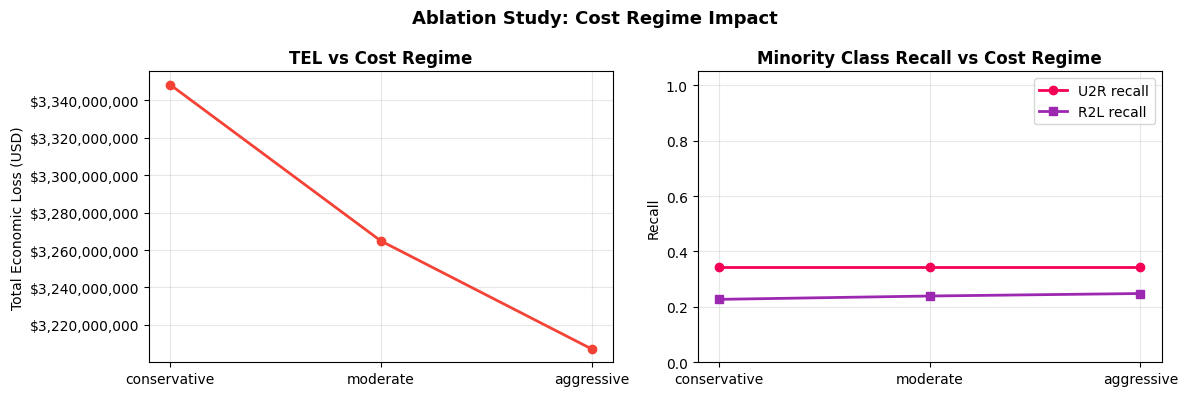

In [31]:
ablation_results = {}
for regime in REGIMES:
    cm_r = get_cost_matrix(regime)
    pred_enc = predict_cost_sensitive(cal_cost_xgb, X_test_scaled, cm_r)
    tel_r = report_tel(y_test_enc, pred_enc, model_name=f'Cost XGB [{regime}]', regime=regime)

    report = cr(y_test_enc, pred_enc, target_names=encoder.classes_, output_dict=True)
    u2r_recall = report.get('U2R', {}).get('recall', 0.0)
    r2l_recall = report.get('R2L', {}).get('recall', 0.0)

    ablation_results[regime] = {
        'tel': tel_r['TEL'],
        'u2r_recall': u2r_recall,
        'r2l_recall': r2l_recall,
    }

plot_ablation(ablation_results)

### Cost Regimes

For each regime we derive sample weights then we retrain, recalibrate and reevaluate XG.

The same architecture and SMOTE'd data is used across all regimes with only weight changes

[16:14:55] [info]: [Ablation] Training cost-sensitive XGB — regime: conservative
[16:15:10] [info]: 
[Ablation — conservative] Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.89      7460
      Normal       0.70      0.97      0.81      9711
       Probe       0.85      0.71      0.77      2421
         R2L       0.98      0.19      0.32      2885
         U2R       0.61      0.33      0.43        67

    accuracy                           0.80     22544
   macro avg       0.82      0.61      0.65     22544
weighted avg       0.84      0.80      0.77     22544


──────────────────────────────────────────────────
  Total Economic Loss — Cost-XGB [conservative] [moderate]
──────────────────────────────────────────────────
  TEL (total):     $3,573,898,562.50
  TEL from FN:     $3,573,895,000.00
  TEL from FP:     $       3,562.50

  FN breakdown:
    U2R     :     $ 119,700,000.00
    R2L     :     $2,772,000,000.00
 

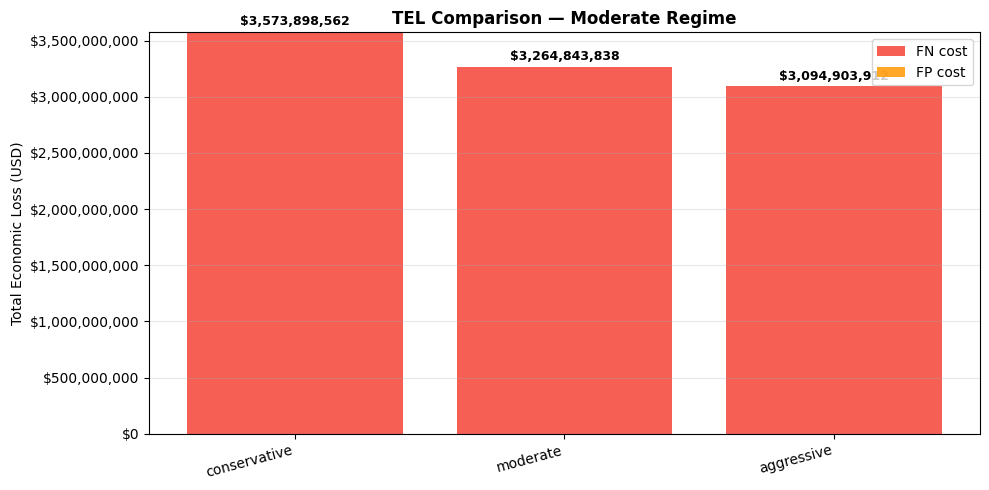

In [32]:
ablation_models = {}
ablation_preds  = {}
ablation_tel    = {}

for regime in REGIMES:
    log.info(f"[Ablation] Training cost-sensitive XGB — regime: {regime}")

    sample_weights = get_sample_weights(y_train_res, regime=regime)
    cost_matrix    = get_cost_matrix(regime=regime)

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb.fit(X_train_res, y_train_res, sample_weight=sample_weights)

    cal_xgb = calibrate(xgb, X_calib, y_calib_enc)

    preds_enc  = predict_cost_sensitive(cal_xgb, X_test_scaled, cost_matrix)
    preds_labels = encoder.inverse_transform(preds_enc)

    ablation_models[regime] = cal_xgb
    ablation_preds[regime]  = preds_enc

    log.info(f"\n[Ablation — {regime}] Classification Report:")
    log.blank(cr(
        encoder.inverse_transform(y_test_enc),
        preds_labels,
        target_names=encoder.classes_
    ))

    ablation_tel[regime] = report_tel(y_test_enc, preds_enc, f"Cost-XGB [{regime}]")

log.info("\n[Ablation] TEL comparison across regimes:")
compare_tel(ablation_tel)

## Cost-Sensitive Corrections

In [33]:
from Xai import find_corrected_samples

for target_class in ("R2L", "U2R"):
    cls_idx = CLASS_TO_IDX[target_class]

    baseline_simple = np.argmax(
        raw_xai_models["baseline"].predict_proba(X_test_scaled), axis=1
    )
    aggressive_cost = np.argmax(
        raw_xai_models["aggressive"].predict_proba(X_test_scaled), axis=1
    )

    corrected_idx = find_corrected_samples(
        y_test_enc, baseline_simple, aggressive_cost, cls_idx
    )

    shap_vals = xai_results["shap_values_dict"]["aggressive"]
    n_shap    = shap_vals.shape[0]  # size of X_sample

    # Filter to indices that exist in the SHAP sample
    corrected_in_sample = Xai.find_corrected_samples_in_shap_sample(
    y_test_enc, baseline_simple, aggressive_cost, cls_idx,
    shap_n_rows=xai_results["shap_values_dict"]["aggressive"].shape[0]
    )

# Results Summary

In [34]:
rows = []
for name in MODELS:
    report = cr(
        y_test_enc,
        preds[name]['cost_enc'],
        target_names=encoder.classes_,
        output_dict=True,
    )
    rows.append({
        'Model': name,
        'Macro F1': round(report['macro avg']['f1-score'], 3),
        'U2R Recall': round(report.get('U2R', {}).get('recall', 0), 3),
        'R2L Recall': round(report.get('R2L', {}).get('recall', 0), 3),
        'TEL (USD)': f"${tel_results[name]['TEL']:,.0f}",
        'TEL FN (USD)': f"${tel_results[name]['TEL_FN']:,.0f}",
    })

summary = pd.DataFrame(rows).set_index('Model')
log.warn('RESULTS SUMMARY')
log.info(summary.to_string())

[16:15:44] [warning]: RESULTS SUMMARY
[16:15:44] [info]:                     Macro F1  U2R Recall  R2L Recall       TEL (USD)    TEL FN (USD)
Model                                                                               
Baseline RF            0.556       0.090       0.063  $4,093,873,725  $4,093,870,000
Cost-Sensitive RF      0.611       0.284       0.095  $3,908,598,750  $3,908,595,000
Baseline XGB           0.574       0.104       0.089  $4,036,343,550  $4,036,340,000
Cost-Sensitive XGB     0.669       0.343       0.239  $3,264,843,838  $3,264,840,000
